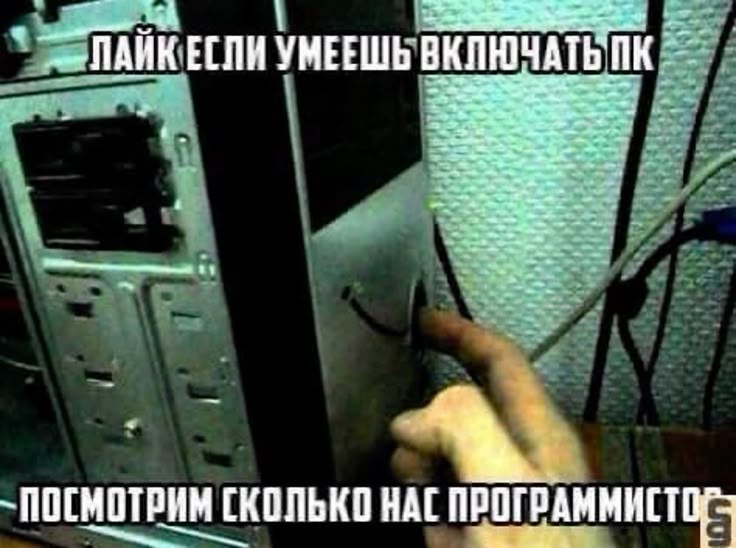

# Первая часть консультации для группы Буйловой М.А. ✌

## 1. Основные понятия теории графов (теоретико-множественное определение, виды графов, ребер, вершин, компоненты связности). Представления графа в памяти компьютера (с асимптотикой по памяти).

Граф — это нелинейная структура данных, состоящая из вершин и рёбер. Вершины иногда также называют узлами, а рёбра — это линии или дуги, соединяющие любые два узла графа. Более формально граф состоит из множества вершин ($V$) и множества рёбер ($E$). Граф обозначается как $G(V, E)$.

Графы бывают неориентированные (ребро без направления) и ориентированные (дуги со стрелкой).



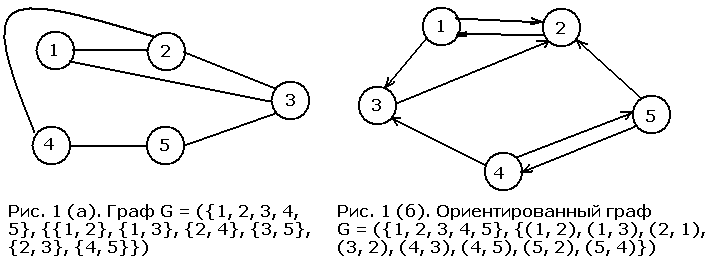

Немного определений:

* **Инцидентность**: ребро инцидентно вершине, если оно к этой вершине «подходит» (является её концом).

* **Степенью вершины** называется число инцидентных ей ребер.

* **Смежность**: две вершины смежны, если между ними есть ребро; два ребра смежны, если имеют общую вершину.

* **Петля** — ребро вида $(v,v)$, то есть соединяет вершину саму с собой.

* **Кратные рёбра** — несколько рёбер между одной и той же парой вершин (такой граф уже не «простой»).

* **Подграф** — граф, полученный из исходного выбором части вершин и части рёбер (все выбранные рёбра должны соединять выбранные вершины).


### Пример неориентированного графа
Рассмотрим граф с 5 вершинами A, B, C, D, E и рёбрами:
A—B, A—C, B—D, C—D, D—E (5 рёбер)

```python
   A
  / \
 B   C
 | -
 D---E
```


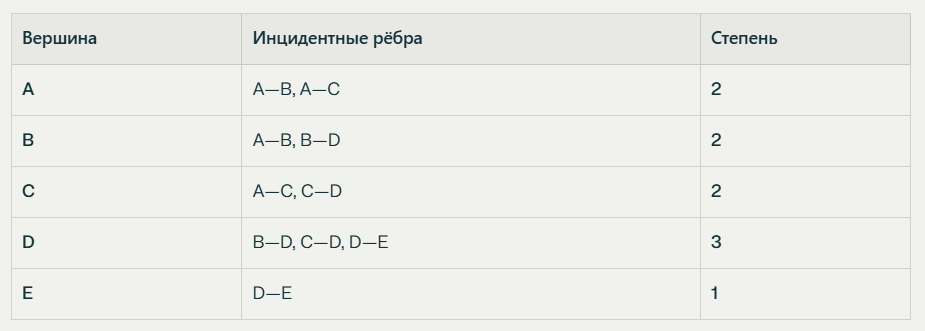

Проверка: сумма степеней = 2+2+2+3+1 = 10 = 2 × 5 (число рёбер). Это **лемма о рукопожатиях**

### Связность и компоненты связности
Неориентированный граф связен, если из любой вершины можно добраться в любую другую по некоторому пути.

* **Компоненты связности** — это максимальные (по включению) связные подграфы: внутри компоненты все достижимы друг из друга, а между разными компонентами путей нет.

### Представление структуры данных графа
Существует несколько способов хранения графа, ниже приведены наиболее распространённые представления:

* Матрицы смежности
* Списки смежности
* Списки рёбер

### Матрица смежности

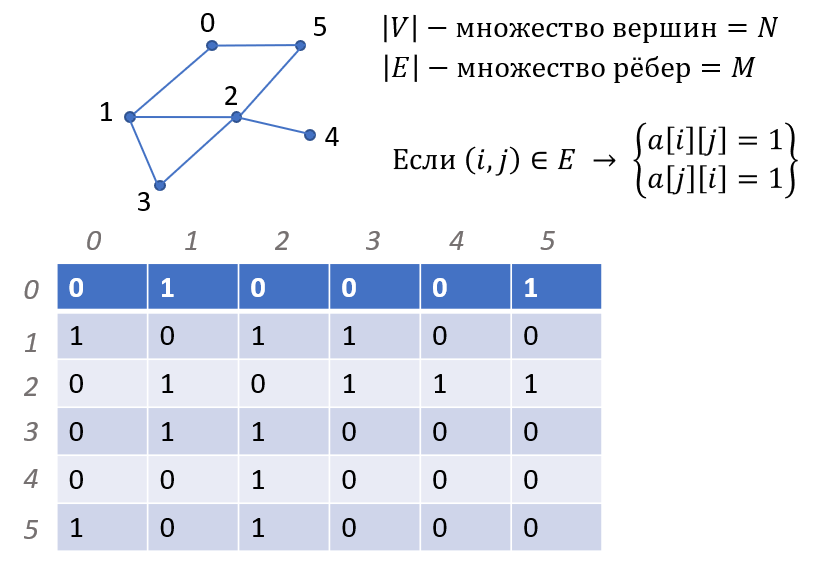

Для неориентированного графа матрица симметричная

In [ ]:
n, m = map(int, input().split())
a = [[0]*n for _ in range(n)]

# считываем рёбра
for i in range(m):
  u, v = map(int, input().split())
  a[u][v] = 1
  a[v][u] = 1


# вывод
for line in a:
  print(*line)

KeyboardInterrupt: Interrupted by user

Память: $O(N^2)$
Время для пробега по всем рёбрам (в общем случае): $O(N^2)$

In [ ]:
for i in range(n):
  for j in range(i, n):
    if a[i][j] == 1:
      print('({}, {})'.format(i, j))

(0, 1)
(0, 5)
(1, 2)
(1, 3)
(2, 3)
(2, 4)
(2, 5)


### Список рёбер
```python
edges = [(0, 1), (0, 5), (1, 2), (1, 3), (2, 4), (5, 2), (3, 2)]
Если граф взвешенный, то храним ещё и вес: (u, v, w)
```

In [ ]:
m = int(input().split())
edges = []
for i in range(m):
  u, v = map(int, input().split())
  edges.append((u, v))

Память: $O(m)$
Время: $O(m)$

### Список смежности
```python
adj_list = {
  0: [1,5],
  1: [0, 3, 2],
  2: [1, 5, 3, 4],
  3: [1, 2],
  4: [2],
  5: [0, 2]}
```

In [ ]:
adj_list = [[] for _ in range(n)]

for i in range(m):
  u, v = map(int, input().split())
  adj_list[u].append(v)
  adj_list[v].append(u)

for u in range(n):
  for v in adj_list[u]:
    print('({}, {})'.format(u, v))

0 1
0 5
1 3
1 2
2 5
2 3
2 4
(0, 1)
(0, 5)
(1, 0)
(1, 3)
(1, 2)
(2, 1)
(2, 5)
(2, 3)
(2, 4)
(3, 1)
(3, 2)
(4, 2)
(5, 0)
(5, 2)


In [ ]:
print(adj_list)

[[1, 5], [0, 3, 2], [1, 5, 3, 4], [1, 2], [2], [0, 2]]


Асимптотика по памяти: $O(m)$

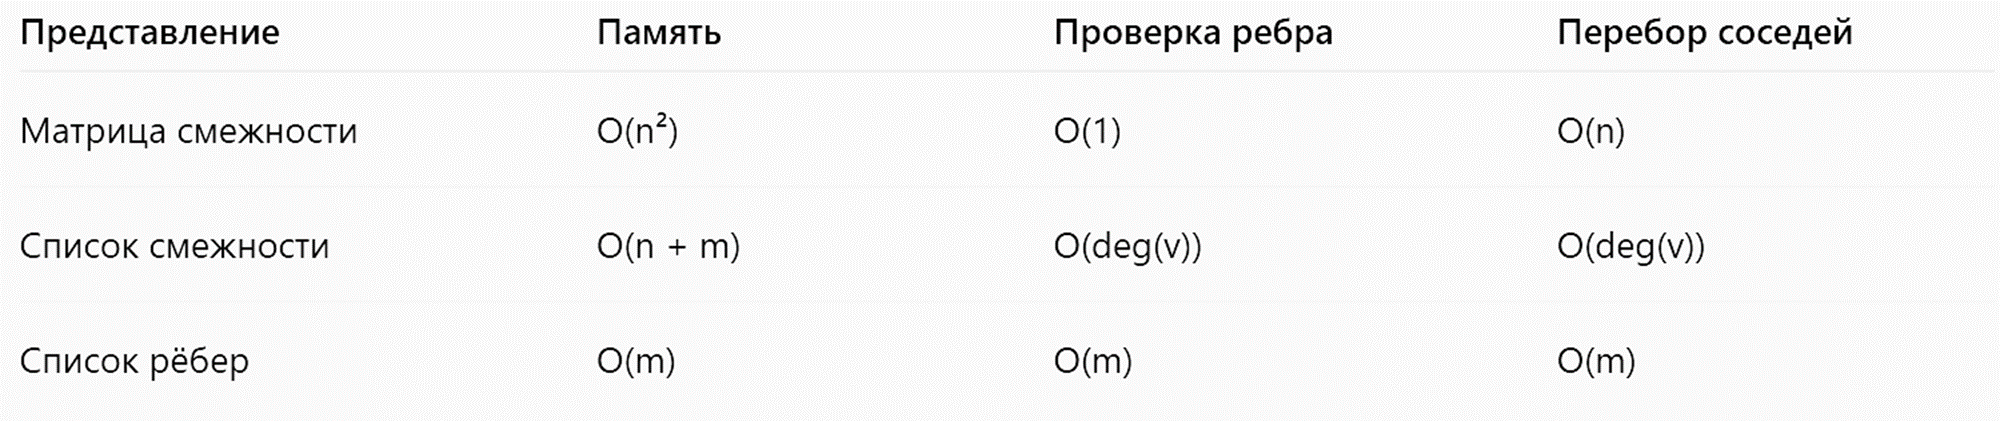

## 2. Обход в глубину– рекурсивный и нерекурсивный подход.

**Поиск в глубину (DFS, Depth-First Search)** — это алгоритм обхода графа, который идёт "вглубь" по одному пути до упора, а потом возвращается назад и пробует другие ветки. В отличие от BFS (слоями), DFS похож на исследование лабиринта с фонариком: идёшь по коридору до тупика, потом разворачиваешься.

Если кратко:
* Берём стартовую вершину
* Идём в любого непосещённого соседа
* Повторяем
* Если идти некуда → возвращаемся назад

Ещё вариант интерпретации:

1. Начать с вершины $u$
2. Покрасить в серый
3. Посетить белых соседей вершины $u$ (рекурсивно)
4. Окрасить вершину $u$ в черный.

=> Возможна проверка на ацикличность:
Когда нашли уже серого соседа - нашли цикл

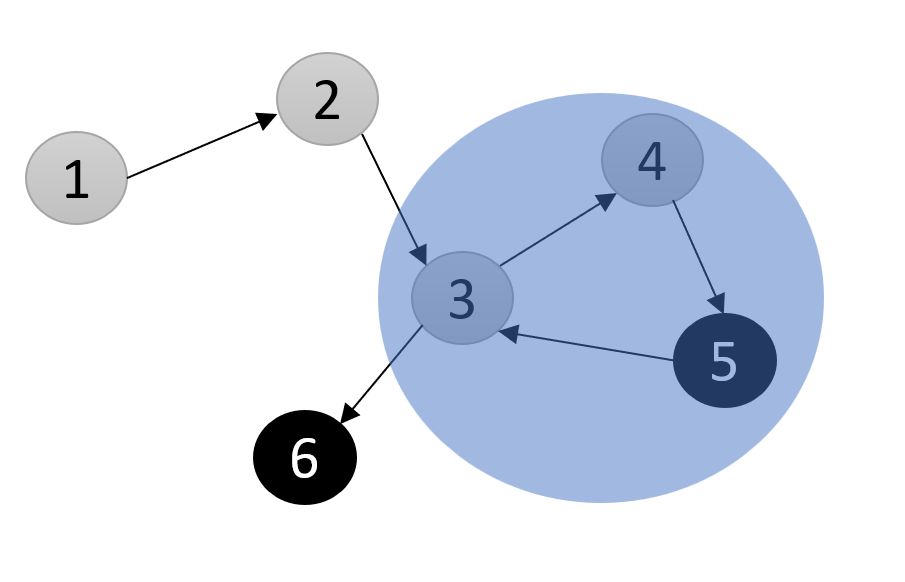

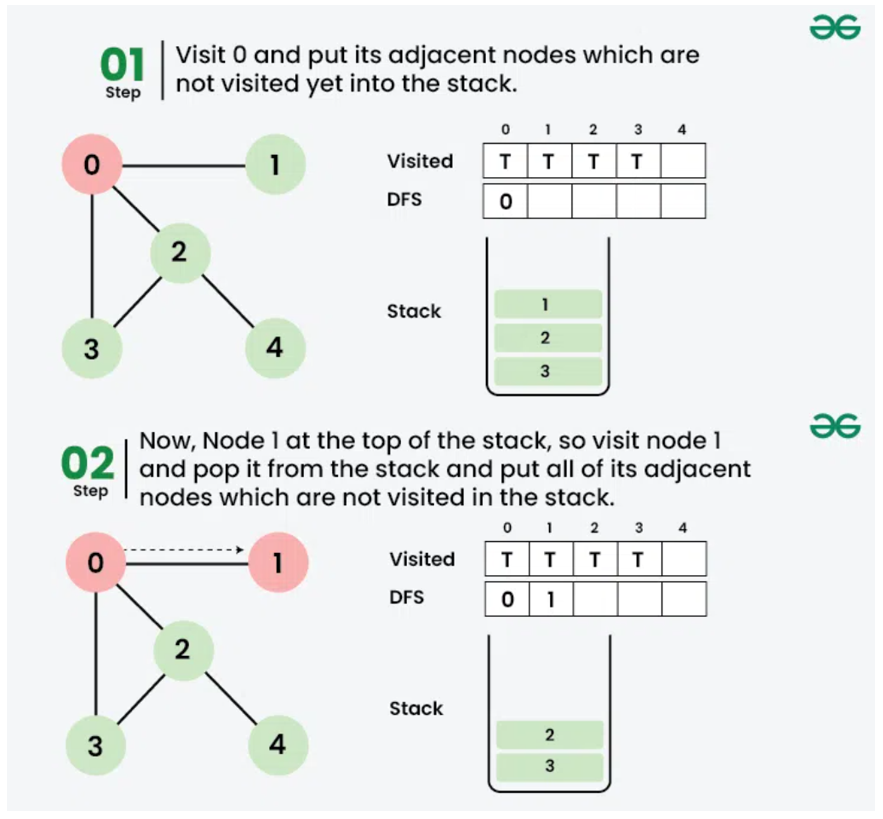

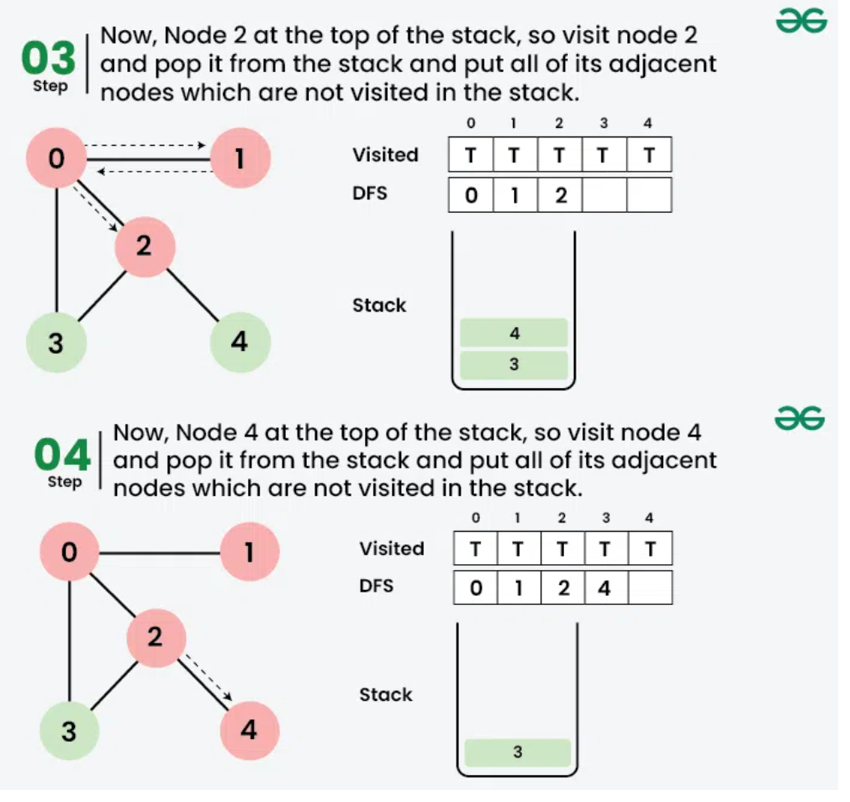

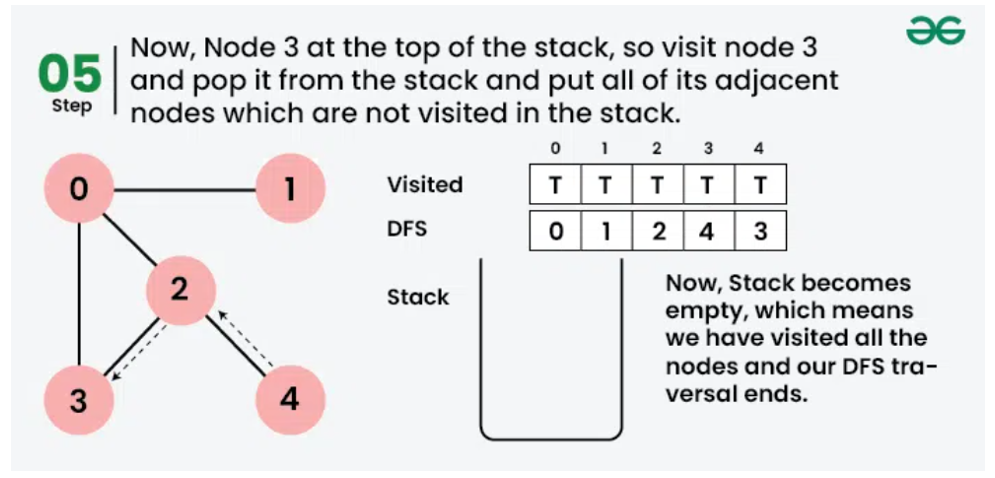

In [ ]:
def dfs(graph, start):
    visited = [False] * len(graph)
    stack = [start]

    while stack:
        u = stack.pop()  # LIFO!
        if not visited[u]:
            visited[u] = True
            print(f"Посещаем {u}")
            # Добавляем соседей в обратном порядке (важно!)
            for v in reversed(graph[u]):
                if not visited[v]:
                    stack.append(v)

graph = [
    [1,2,3],
    [0],
    [0,3,4],
    [0,2],
    [2]  ]

dfs(graph, 0)

Посещаем 0
Посещаем 1
Посещаем 2
Посещаем 3
Посещаем 4


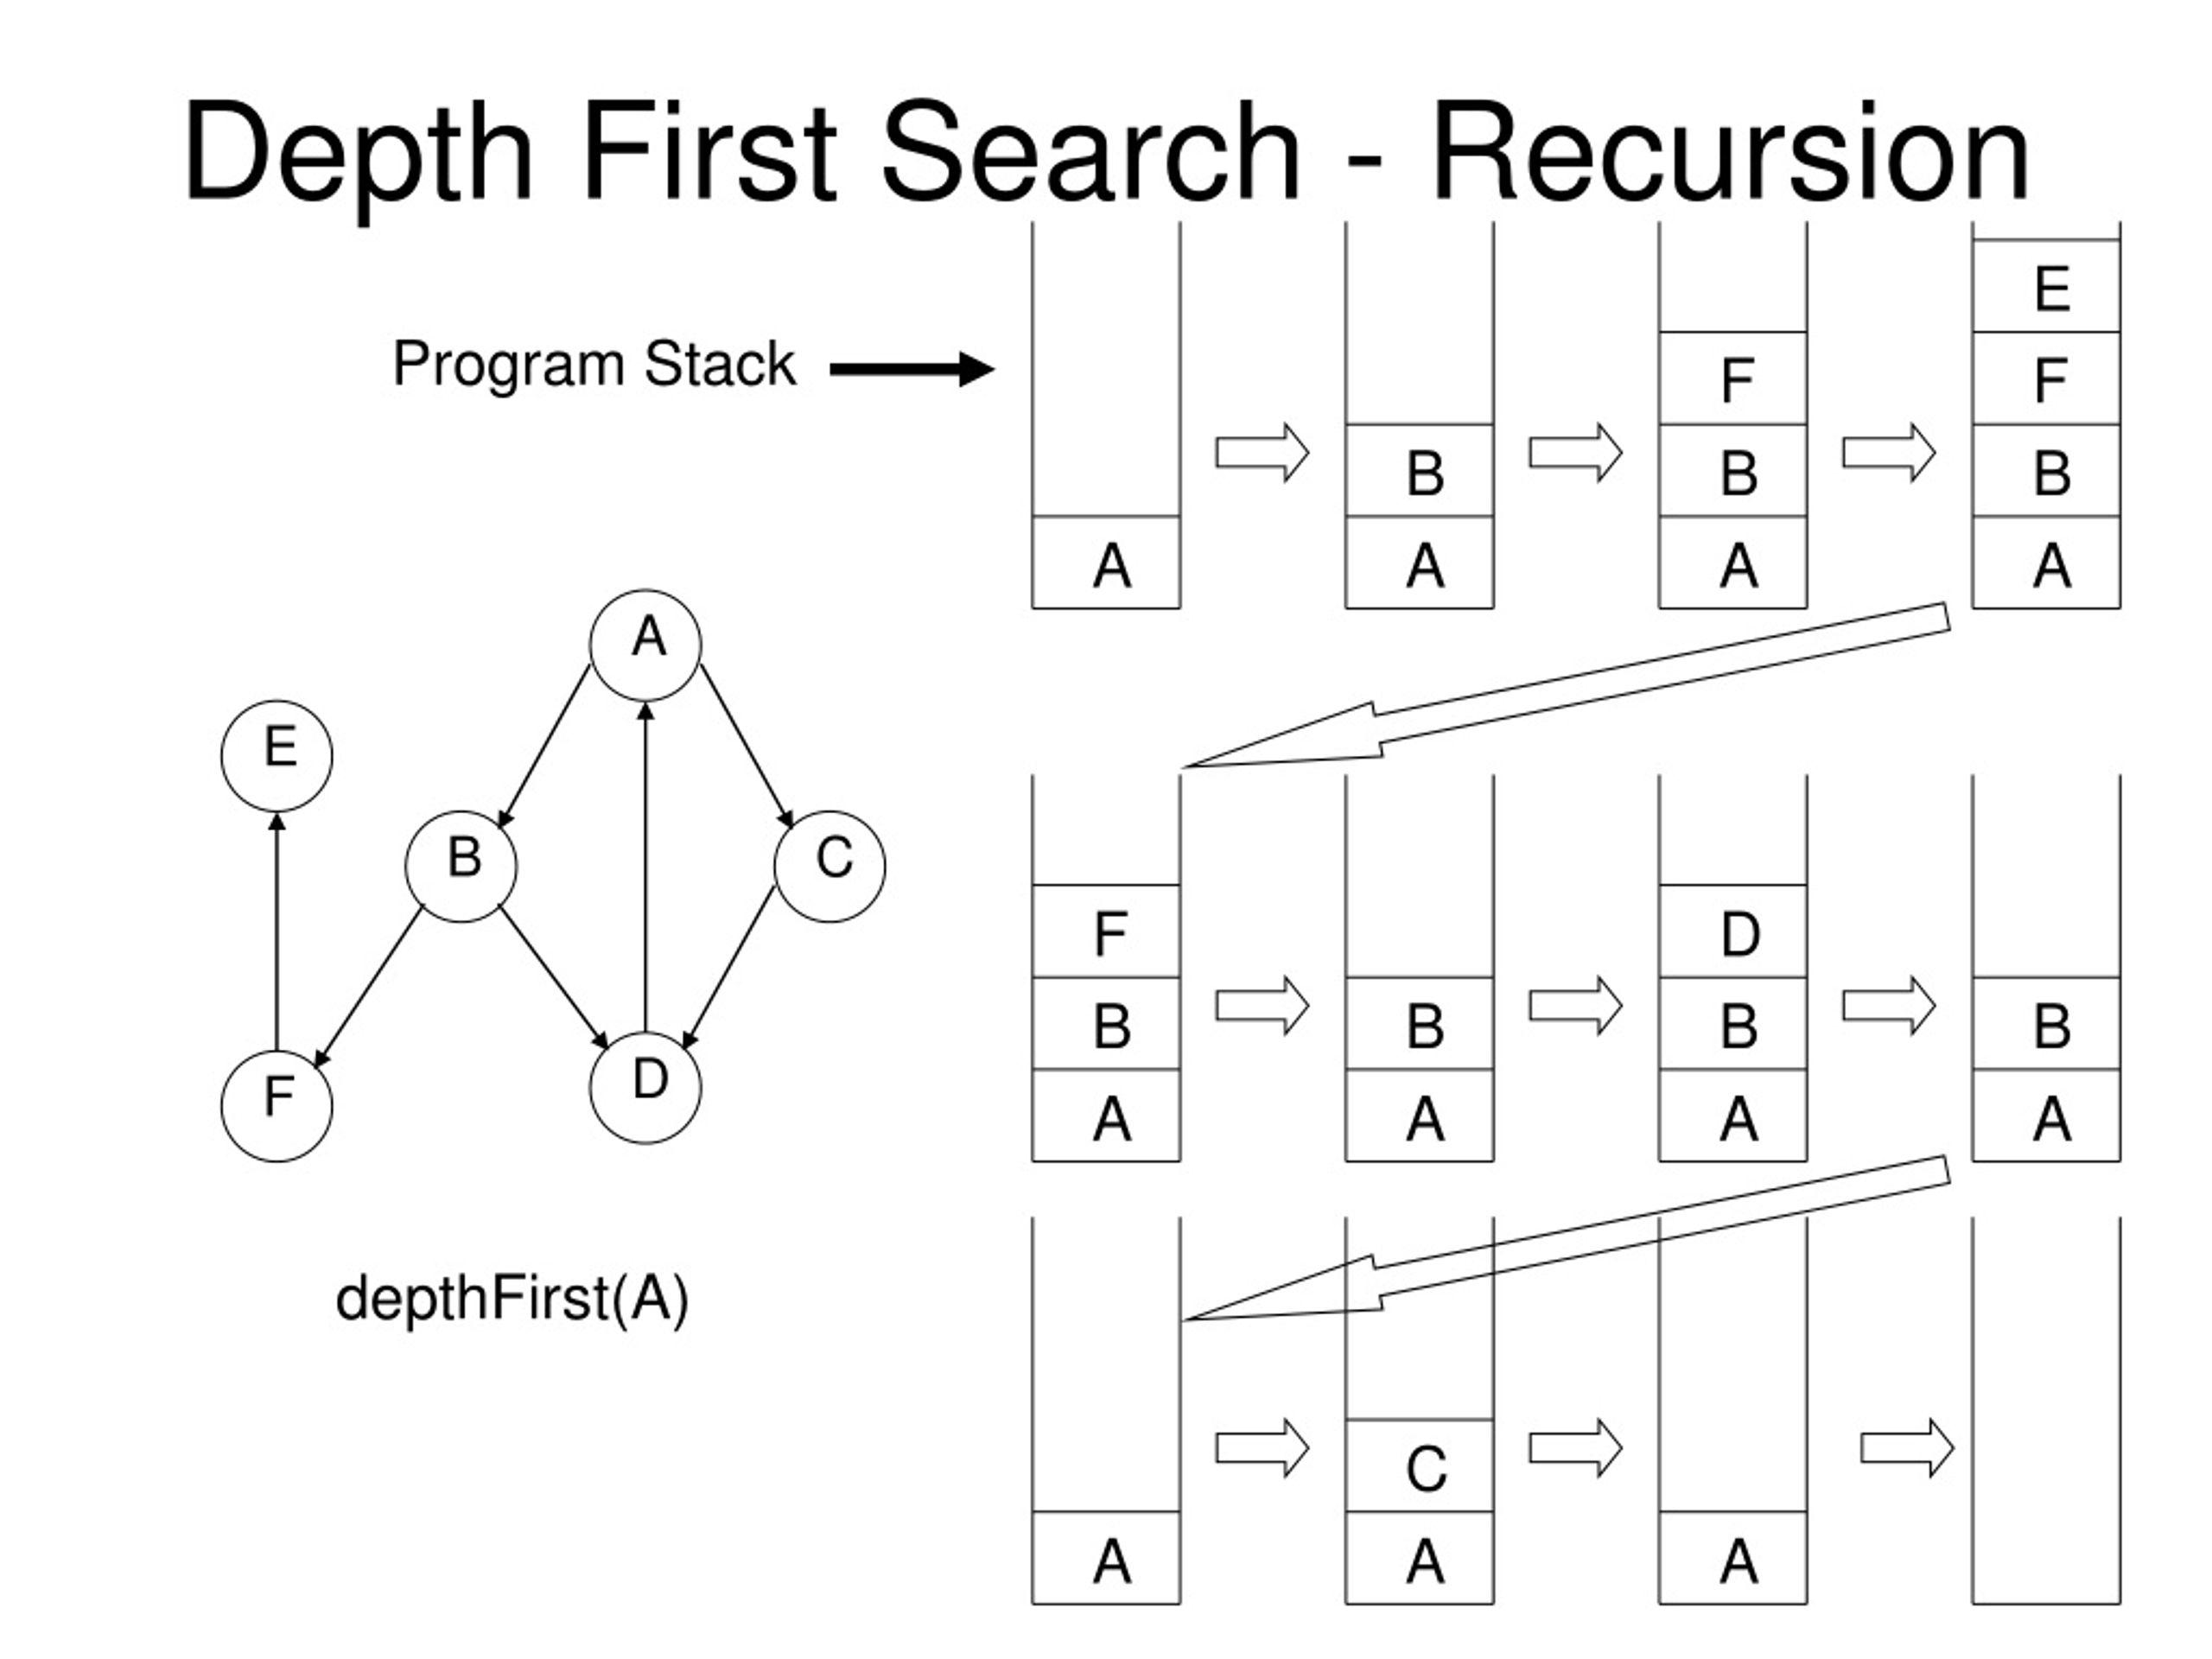

Рекурсивная версия:

In [ ]:
def dfs_recursive(graph, u, visited):
    visited[u] = True
    print(f"Посещаем {u}")

    for v in graph[u]:
        if not visited[v]:
            dfs_recursive(graph, v, visited)

# Запуск
graph = [
    [1,2,3],
    [0],
    [0,3,4],
    [0,2],
    [2]
]
visited = [False] * 5
dfs_recursive(graph, 0, visited)


Время: $O(n + m)$

Память: $O(n)$

## 3. Обход в ширину– рекурсивный и нерекурсивный подход

**Поиск в ширину (BFS, Breadth-First Search)** — это алгоритм обхода графа, который исследует граф "слоями" по возрастанию расстояния от стартовой вершины. Он находит кратчайшие пути по количеству рёбер в невзвешенных графах.

На вход алгоритма подаётся невзвешенный граф и номер стартовой вершины $s$. Граф может быть как ориентированным, так и неориентированным — для алгоритма это не важно.

Основную идею алгоритма можно понимать как процесс «поджигания» графа: на нулевом шаге мы поджигаем вершину $s$, а на каждом следующем шаге огонь с каждой уже горящей вершины перекидывается на всех её соседей, в конечном счете поджигая весь граф.

BFS сначала проверяет всех соседей стартовой вершины, потом соседей соседей, и т.д.



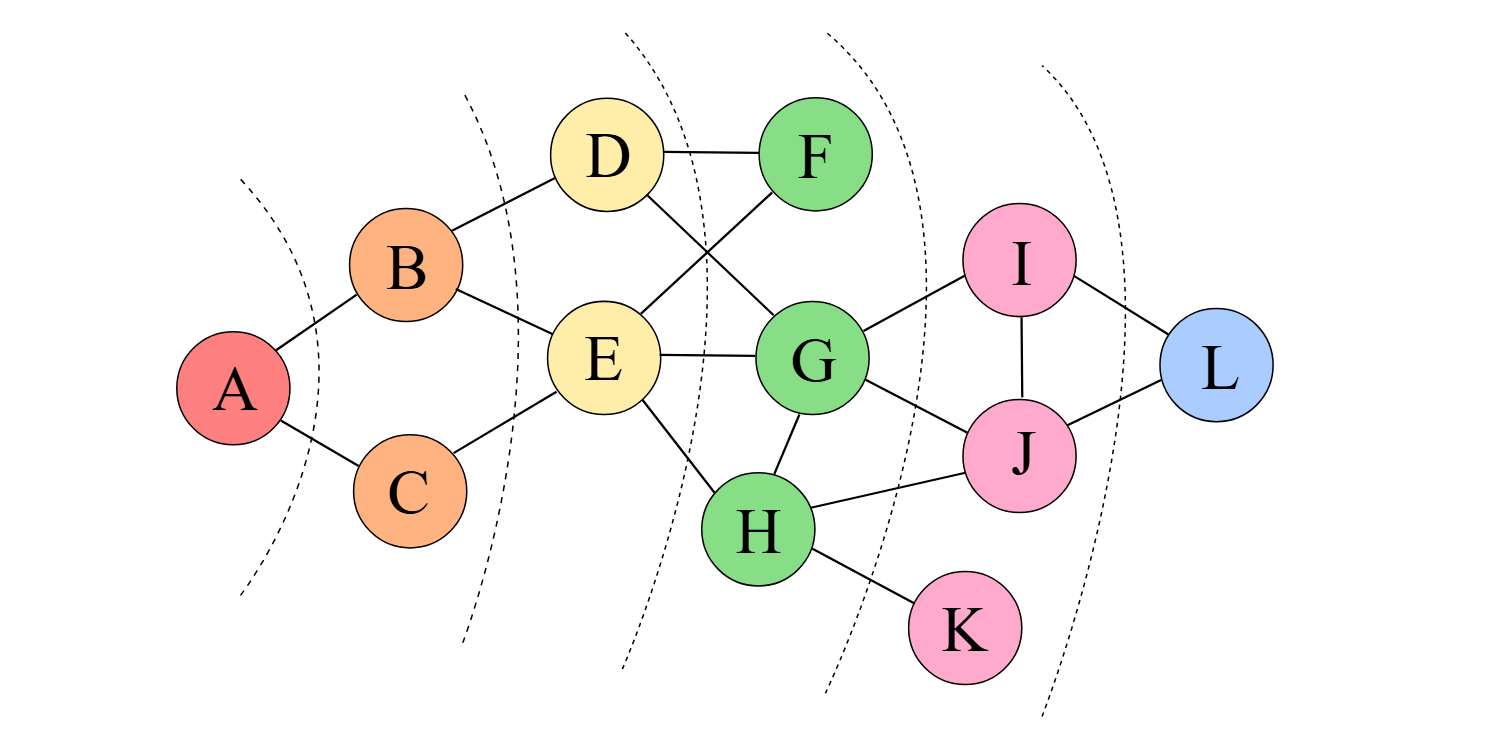

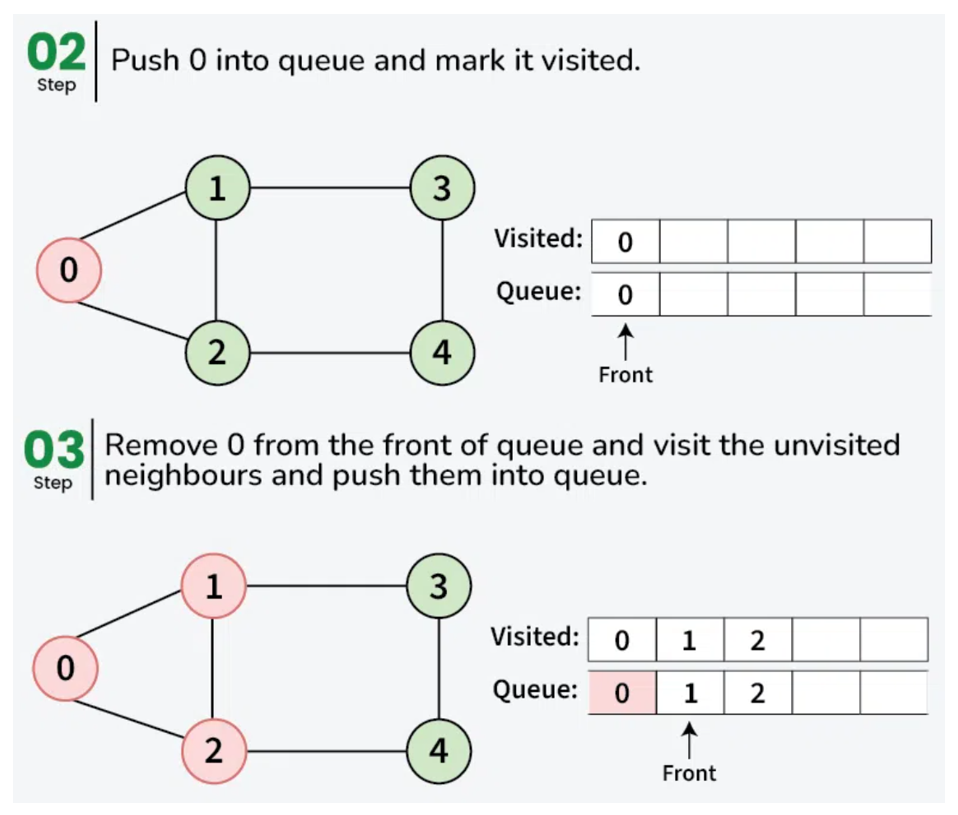

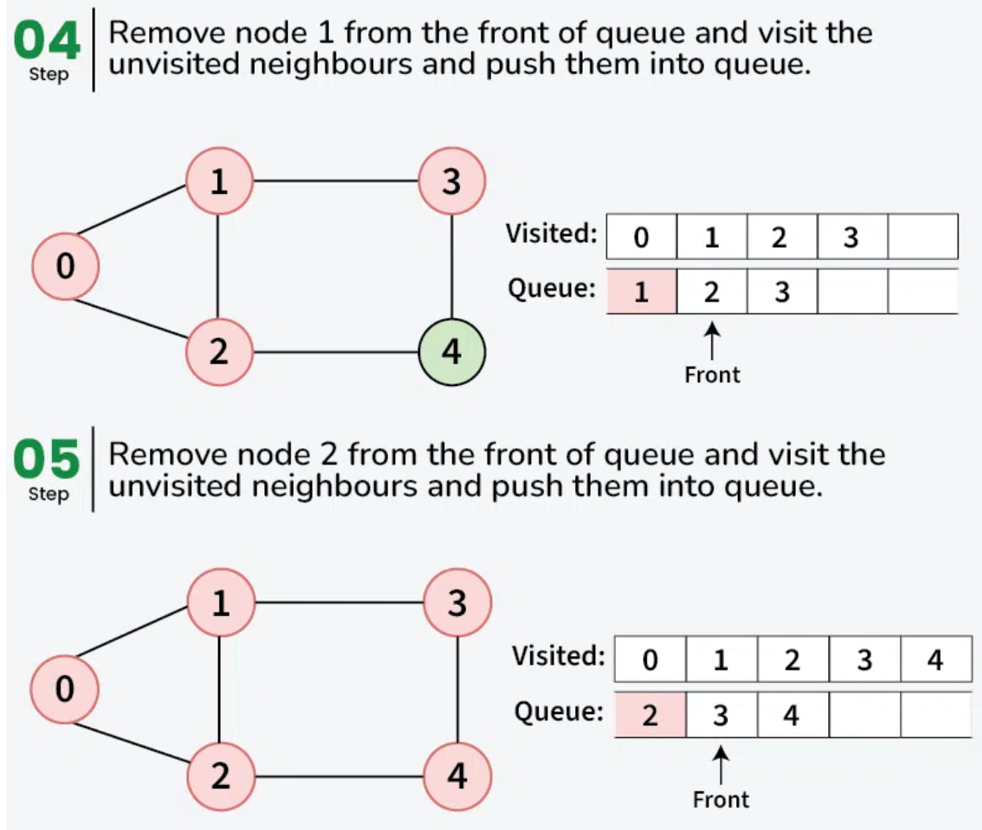

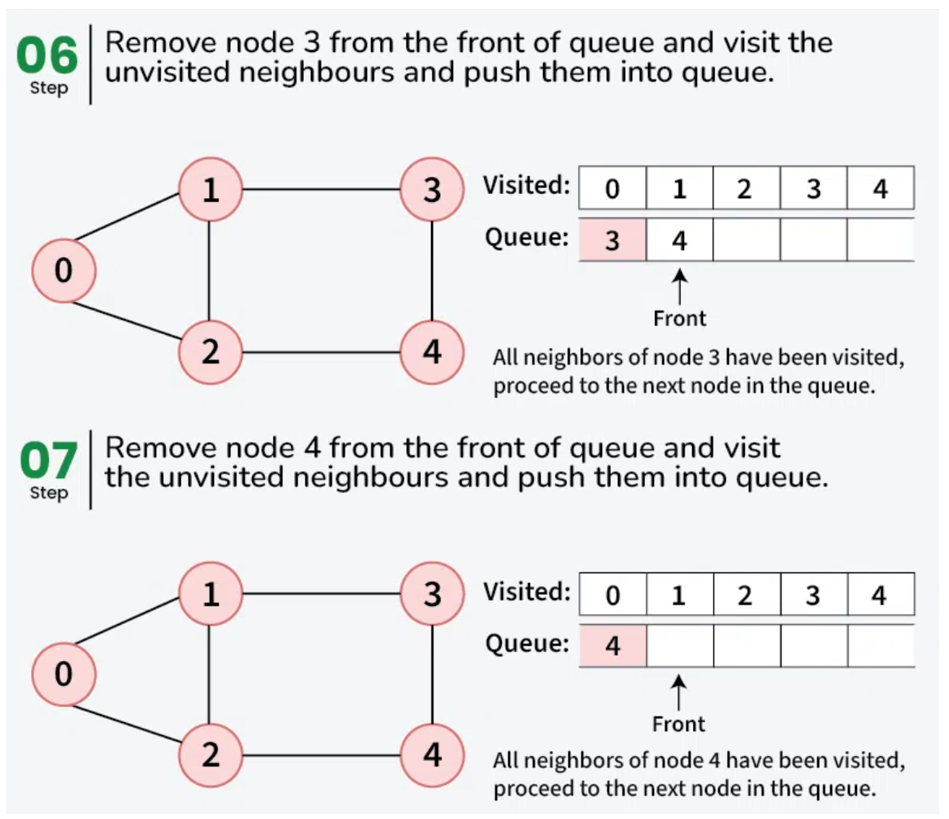

### Нерекурсивный BFS (классический)
* используем очередь (FIFO)
* обрабатываем вершины по уровням



In [ ]:
from collections import deque

def bfs(graph, start):
    visited = set([start])
    queue = deque([start])

    while queue:
        v = queue.popleft()
        print(v)

        for neighbor in graph[v]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

Время: $O(n + m)$  
Память: $O(n)$  
Гарантирует кратчайший путь (в невзвешенном графе)

### Рекурсивный BFS (через уровни)

* храним текущий уровень вершин
* строим следующий уровень
* рекурсивно вызываем функцию

In [ ]:
def bfs_recursive(graph, current_level, visited):
    if not current_level:
        return

    next_level = []

    for v in current_level:
        print(v)

        for neighbor in graph[v]:
            if neighbor not in visited:
                visited.add(neighbor)
                next_level.append(neighbor)

    bfs_recursive(graph, next_level, visited)


graph = {
    0: [1, 2],
    1: [0, 2, 3],
    2: [0, 1, 4],
    3: [1, 4],
    4: [2, 3]
}

visited = set([0])
bfs_recursive(graph, [0], visited)

0
1
2
3
4


## 4. Алгоритм Дейкстры. Асимптотика и ограничения алгоритма.

Имея граф и исходную вершину в графе, найдите самые короткие пути от источника ко всем вершинам в данном графе. Алгоритм Дейкстры — популярный алгоритм для решения многих задач с одним источником на короткий путь с неотрицательным весом рёбер в графах, то есть он предназначен для поиска самого короткого расстояния между двумя вершинами на графе. Он был задуман голландским компьютерным учёным Эдсгером В. Дейкстрой в 1956 году.

Существует два основных варианта алгоритма, время работы которых составляет $O(n^2)$ и $O(mlogn)$, где $n$ — число вершин, а $m$ — число ребер.

Заведём массив $d$, в котором для каждой вершины $v$ будем хранить текущую длину $d_v$ кратчайшего пути из s в v. Изначально
$d_s = 0$, а для всех остальных вершин расстояние равно бесконечности (или любому числу, которое заведомо больше максимально возможного расстояния).

Во время работы алгоритма мы будем постепенно обновлять этот массив, находя более оптимальные пути к вершинам и уменьшая расстояние до них. Когда мы узнаем, что найденный путь до какой-то вершины v оптимальный, мы будем помечать эту вершину, поставив единицу ($a_v = 1$) в специальном массиве $a$, изначально заполненном нулями.

Сам алгоритм состоит из n итераций, на каждой из которых выбирается вершина $v$ с наименьшей величиной $d_v$ среди ещё не помеченных.

Выбранная вершина отмечается в массиве $a$, после чего из из вершины $v$ производятся релаксации: просматриваем все исходящие рёбра $(v,u)$ и для каждой такой вершины $u$ пытаемся улучшить значение $d_u$, выполнив присвоение $d_u = min(d_u,d_v + w)$ где $w$ — длина ребра $(v,u)$.

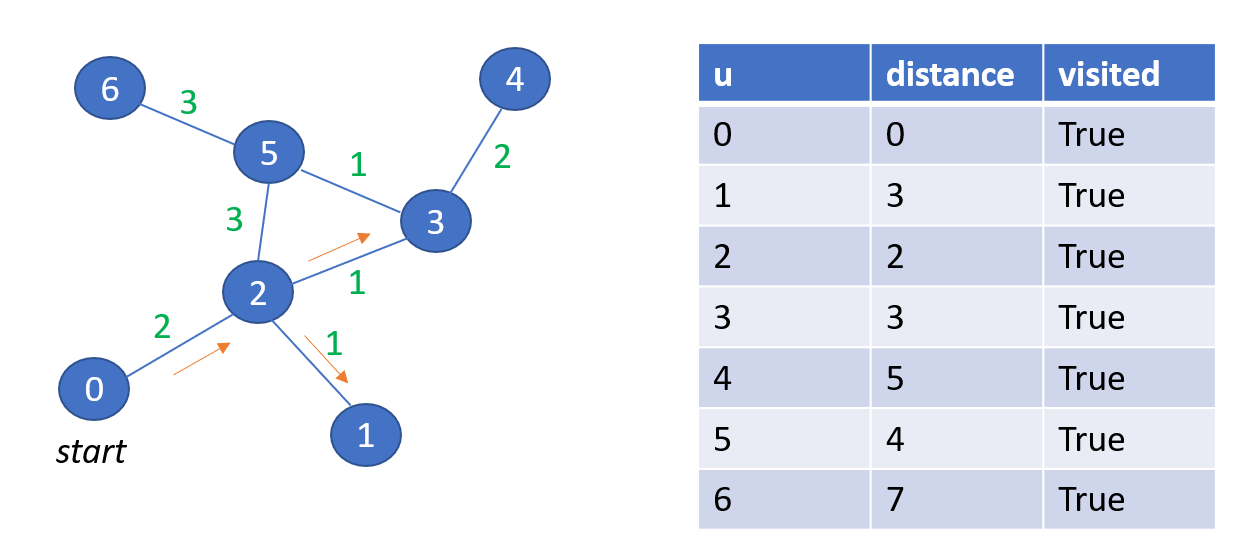

Алгоритм:  
1. ***Инициализация***:   
distance[start] = 0  
visited[u] = False для любой $u$ из графа $G$
2. ***Главный цикл***:  
2.1. Ищем необработанные вершины, для которых расстояние min, $u_{min}$  
2.2. Обработка $u_{min}$, улучшаем расстояние до её соседей  
2.3. Помечаем  $u_{min}$ как обработанную

+ Улучшенный вариант
1. Инициализируем очередь с приоритетом, все вершины кидаем в очередь.
2. Пока heapq не пуста:
```
# heapq — это куча, реализующая очередь с приоритетом
```
2.1. Вытаскиваем $u_{min}$ = heapq.heappop() --- log(V)   
2.2. Обрабатываем $u_{min}$  
2.3. Если улучшили расстояние, добавляем вершину $v$ в очередь --- log(V)  

3. --//--

=> Сложность улучшенной версии: $O(V + V⋅log V + E⋅log V) = O((V+E)⋅log(V))$

https://ru.algorithmica.org/cs/shortest-paths/dijkstra/ - классная гифка


In [ ]:
def dijkstra_simple(graph, start):
    n = len(graph)
    dist = [float('inf')] * n
    dist[start] = 0
    used = [False] * n

    for _ in range(n):
        # Найти ближайшую
        u = -1
        min_d = float('inf')
        for i in range(n):
            if not used[i] and dist[i] < min_d:
                min_d = dist[i]
                u = i

        if u == -1: break
        used[u] = True

        # Обновить соседей
        for v, w in graph[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w

    return dist

# Тест
graph = [[(1,7),(2,5),(3,3)], [(2,1),(4,2)], [(4,3)], [(2,2)], []]
print(dijkstra_simple(graph, 0))

[0, 7, 5, 3, 8]


Классическая версия, сложность $O(V^2)$

In [ ]:
import heapq

def dijkstra(graph, start):
    n = len(graph)
    dist = [float('inf')] * n
    dist[start] = 0

    # (расстояние, вершина)
    pq = [(0, start)]

    print(f"Поиск от вершины {start}")
    print("Шаг | dist | очередь | обновления")
    print("-" * 40)

    step = 0
    while pq:
        d, u = heapq.heappop(pq)
        step += 1

        if d > dist[u]:
            continue

        print(f"{step:2} | {dist} | pq: {pq} | взяли {u}(d={d})")

        for v, weight in graph[u]:
            old_dist = dist[v]
            new_dist = dist[u] + weight

            if new_dist < dist[v]:
                dist[v] = new_dist
                heapq.heappush(pq, (new_dist, v))
                print(f"    → {v}: {old_dist} → {new_dist}")

    return dist

# списки смежности [(сосед, вес), ...]
graph = [
    [(1, 7), (2, 5), (3, 3)],  # из 0
    [(2, 1), (4, 2)],          # из 1
    [(4, 3)],                  # из 2
    [(2, 2)],                  # из 3
    []                         # из 4
]

distances = dijkstra(graph, 0)
print(f"Кратчайшие расстояния от 0: {distances}")

Поиск от вершины 0
Шаг | dist | очередь | обновления
----------------------------------------
 1 | [0, inf, inf, inf, inf] | pq: [] | взяли 0(d=0)
    → 1: inf → 7
    → 2: inf → 5
    → 3: inf → 3
 2 | [0, 7, 5, 3, inf] | pq: [(5, 2), (7, 1)] | взяли 3(d=3)
 3 | [0, 7, 5, 3, inf] | pq: [(7, 1)] | взяли 2(d=5)
    → 4: inf → 8
 4 | [0, 7, 5, 3, 8] | pq: [(8, 4)] | взяли 1(d=7)
 5 | [0, 7, 5, 3, 8] | pq: [] | взяли 4(d=8)
Кратчайшие расстояния от 0: [0, 7, 5, 3, 8]


Сложность: см. выше про описание улучшенной версии

## 5. Минимальное остовное дерево, алгоритмы Борувки, Прима, Краскала (на выбор 1 из 3). Асимптотика работы

Рассмотрим следующую задачу:

Авиакомпания содержит $m$ рейсов между $n$ городами, $i$-ый из них обходится в $w_i$ рублей, причём из любого города можно добраться до любого другого. В стране наступил кризис, и нужно отказаться от как можно большего числа из них таким образом, что содержание оставшихся рейсов будет наиболее дешевым.

Иными словами, нужно найти **дерево минимального веса, которое является подграфом данного неориентированного графа**. Почему дерево? Потому что в противном случае там был бы цикл, из которого можно удалить какое-то ребро и получить более оптимальный ответ. А если это больше, чем одно дерево, то какие-то две вершины остаются несвязны.

Такие деревья называют **остовами** (каркас, скелет; ударение на первый слог, но так мало кто произносит; англ. minimum spanning tree (mst) — дословно, минимальное покрывающее дерево).

* Если остовный подграф является деревом (связным графом без циклов), то он называется остовным деревом, а если еще и имеет наименьшую сумму весов ребер среди всех остовных деревьев, то называется минимальным остовным деревом.

* Разрезом графа называется разбиение вершин графа на два непересекающихся множества. ИЛИ: Разрезом связного графа будем называть подмножество рёбер и вершин, образующих подграф, в котором есть ровно две компоненты связности.
* Ребро пересекает данный разрез, если при его добавлении граф снова становится связным.

* Ребро $(v,u)$ пересекает разрез $(S,U)$, если $v ∈ S, u ∈ U$.

Все алгоритмы для поиска минимального остова опираются на следующее утверждение:

**Лемма о безопасном ребре:**
Рассмотрим произвольный разрез какого-либо подграфа минимального остова. Тогда ребро минимального веса, пересекающее этот разрез, является безопасным.

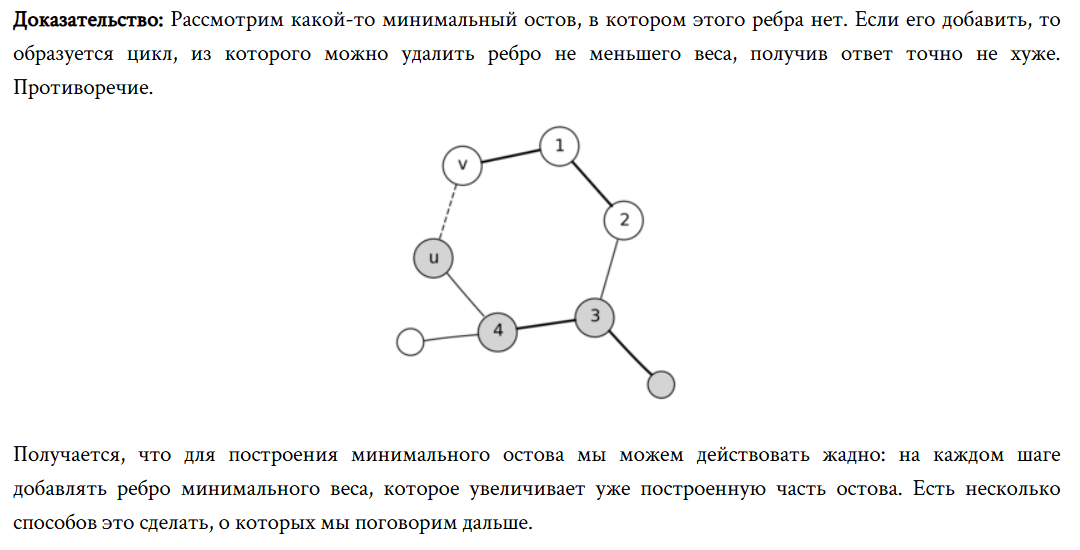

### Алгоритм Прима

Лемма о безопасном ребре говорит, что мы можем строить минимальный остов постепенно, добавляя по одному ребра, про которые мы точно знаем, что они минимальные для соединения какого-то разреза.

Один из подходов это использовать заключается в алгоритме Прима:

* Изначально остов — одна произвольная вершина.
* Пока минимальный остов не найден, выбирается ребро минимального веса, исходящее из какой-нибудь вершины текущего остова в вершину, которую мы ещё не добавили. Добавляем это ребро в остов и начинаем заново, пока остов не будет найден.


Этот алгоритм очень похож на алгоритм Дейкстры, только мы выбираем следующую вершину с другой весовой функцией — вес минимального соединяющего ребра вместо суммарного расстояния до неё.

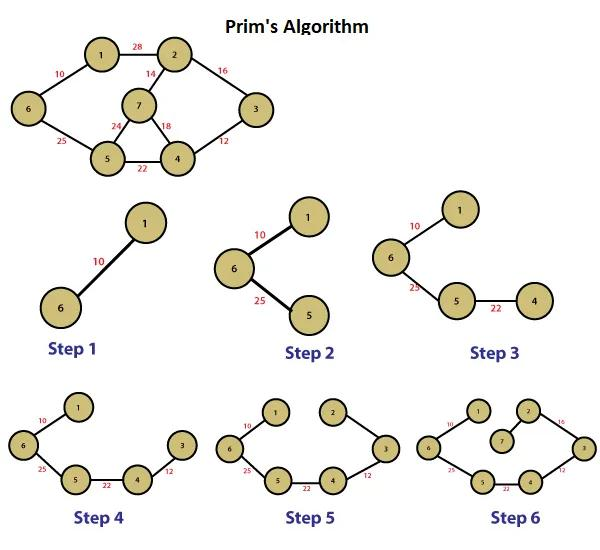

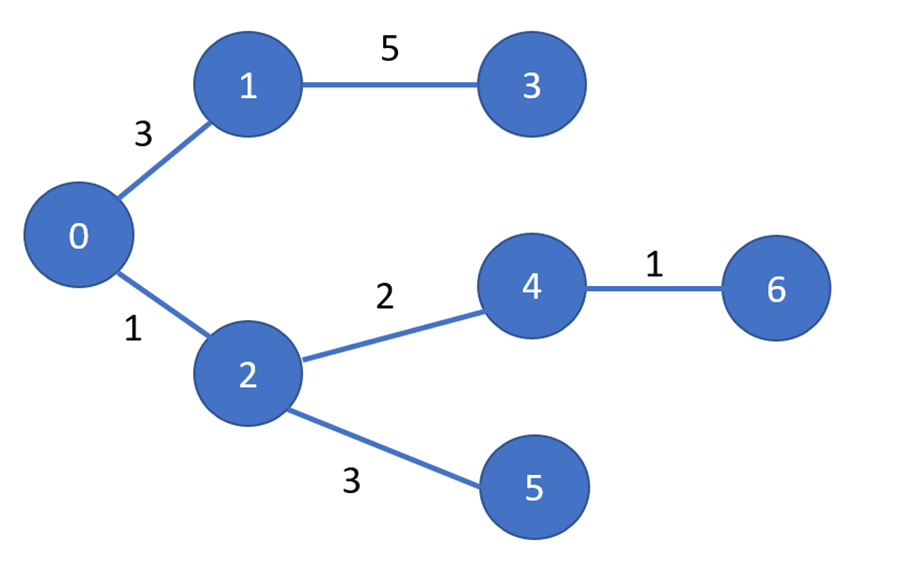

In [ ]:
import heapq

def prim(graph, n):
    """
    Алгоритм Прима для MST
    graph: [[(v, w), ...], ...] - списки смежности
    """
    INF = float('inf')
    min_edge = [INF] * n          # min вес до дерева
    used = [False] * n            # в MST?
    parent = [-1] * n             # для восстановления пути
    min_edge[0] = 0               # старт с вершины 0

    pq = [(0, 0)]                 # (вес, вершина)

    mst_weight = 0

    while pq:
        weight, u = heapq.heappop(pq)
        if used[u] or weight > min_edge[u]:
            continue

        used[u] = True
        mst_weight += weight

        for v, w in graph[u]:
            if not used[v] and w < min_edge[v]:
                min_edge[v] = w
                parent[v] = u
                heapq.heappush(pq, (w, v))

    return mst_weight, parent

# Тестовый граф
graph = [
    [(2,1), (1,3)],      # 0
    [(0,3), (3,5)],      # 1
    [(0,1), (4,2), (5,3)], # 2
    [(1,5)],             # 3
    [(2,2), (6,1)],      # 4
    [(2,3)],             # 5
    [(4,1)]              # 6
]

weight, tree = prim(graph, 7)
print(f"MST вес: {weight}")  # 15
print("Дерево:", tree)       # [-1, 0, 0, 1, 2, 2, 4]

MST вес: 15
Дерево: [-1, 0, 0, 1, 2, 2, 4]


```python
Итерация | Дерево | Добавили | Вес
0        | {0}    | 0→2      | 1
1        | {0,2}  | 2→4      | 2
2        | {0,2,4}| 4→6      | 1
3        | {0,2,4,6} | 0→1   | 3
4        | {0,1,2,4,6} | 1→3 | 5
5        | {0,1,2,3,4,6} | 2→5 | 3
ИТОГО    | {0-6}  |          | **15**
```

```python
Значение | Вершина | Родитель | Ребро MST
---------|---------|----------|----------
-1       | **0**   | **корень** | -
0        | **1**   | **0**    | **0→1 (вес 3)**
0        | **2**   | **0**    | **0→2 (вес 1)**
1        | **3**   | **1**    | **1→3 (вес 5)**
2        | **4**   | **2**    | **2→4 (вес 2)**
2        | **5**   | **2**    | **2→5 (вес 3)**
4        | **6**   | **4**    | **4→6 (вес 1)**
```

In [ ]:
def prim_simple(graph, n):
    used = [False] * n
    min_edge = [float('inf')] * n
    min_edge[0] = 0

    mst_weight = 0
    edges = []

    for _ in range(n):
        # Найти непосещённую с min весом
        u = -1
        for i in range(n):
            if not used[i] and (u == -1 or min_edge[i] < min_edge[u]):
                u = i

        used[u] = True
        mst_weight += min_edge[u]

        # Обновить соседей
        for v, w in graph[u]:
            if not used[v] and w < min_edge[v]:
                min_edge[v] = w

    return mst_weight


graph = [
    [(2,1), (1,3)],      # 0
    [(0,3), (3,5)],      # 1
    [(0,1), (4,2), (5,3)], # 2
    [(1,5)],             # 3
    [(2,2), (6,1)],      # 4
    [(2,3)],             # 5
    [(4,1)]              # 6
]
weight = prim_simple(graph, 7)
print(f"MST вес: {weight}")

MST вес: 15


Сложность:

* Простая реализация:	$O(V^2)$
* С кучей:	$O((V+E)logV)$

### Алгоритм Краскала

Другой способ использовать лемму о безопасном ребре — отсортировать все ребра и пытаться добавлять их в изначально пустой остов в порядке возрастания их весов.

Если очередное ребро соединяет какие-то две уже соединенные вершины, то проигнорируем его. Иначе оно является безопасным, так как оно минимальное из соединяющих какие-то две различные компоненты, и его можно добавить.

Звучит очень просто: отсортировать все рёбра, пройтись по ним циклом и делать проверку, что вершины в разных компонентах. Но наивная проверка dfs-ом от концов всех ребер будет работать за $O(nm)$. Асимптотику можно улучшить до $O(mlogm)$ — до стоимости сортировки ребер — если для проверок использовать систему непересекающихся множеств.

In [ ]:
def kruskal(graph_edges, n):
    """
    graph_edges: list[(w, u, v)]
    """
    # Сортируем рёбра
    graph_edges.sort()
    #print(graph_edges)

    # Изначально каждый = своей компоненте
    component = list(range(n))  # component[i] = группа i

    mst_edges = []
    mst_weight = 0

    def same_component(u, v):
        """В одной компоненте?"""
        return component[u] == component[v]

    def merge_components(u, v):
        """Объединить компоненты"""
        cu, cv = component[u], component[v]
        if cu != cv:
            # Меняем всю группу cv на cu
            for i in range(n):
                if component[i] == cv:
                    component[i] = cu
            return True
        return False

    # Добавляем рёбра по весу
    for w, u, v in graph_edges:
        if not same_component(u, v):  # не цикл?
            if merge_components(u, v):
                mst_edges.append((w, u, v))
                mst_weight += w

    return mst_edges, mst_weight

# Тест
graph_edges = [
    (1, 0, 2), (3, 0, 1), (2, 1, 3), (5, 1, 3),
    (2, 2, 4), (3, 2, 5), (1, 4, 6)
]

n = 7
mst_edges, weight = kruskal(graph_edges, n)
print(f"MST вес: {weight}")
print("Рёбра:", mst_edges)


MST вес: 12
Рёбра: [(1, 0, 2), (1, 4, 6), (2, 1, 3), (2, 2, 4), (3, 0, 1), (3, 2, 5)]


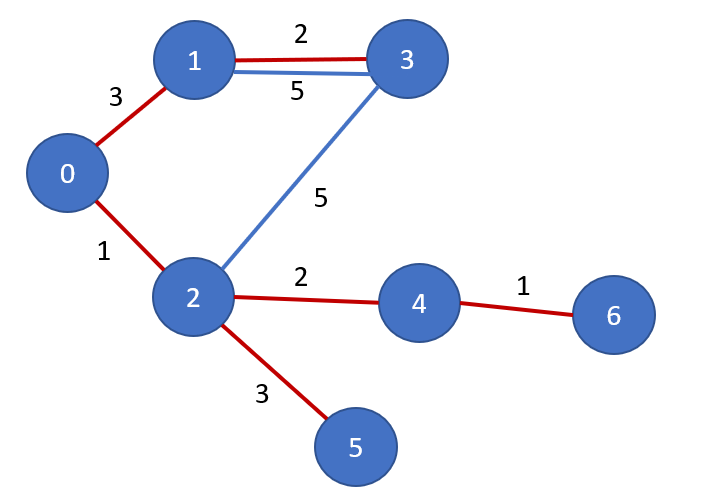

In [ ]:
# Маленький граф
edges = [(2,0,1), (3,0,2), (1,1,2)]
print(kruskal(edges, 3))  # вес 3, рёбра [(1,1,2),(2,0,1)]


([(1, 1, 2), (2, 0, 1)], 3)


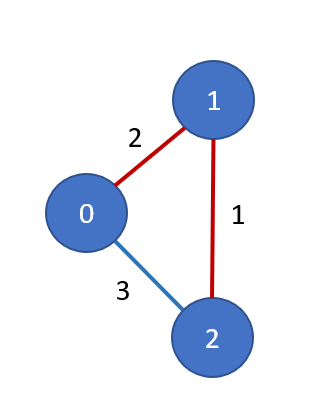

### Алгоритм Борувки

Переформулируем лемму о безопасном ребре в частном случае:

**Лемма.** Для любой вершины минимальное инцидентное ей реборо является безопасным.

**Доказательство.** Пусть есть минимальный остов, в котором для какой-то вершины $v$ нет её минимального инцидентного ребра. Тогда, если добавить это ребро, образуется цикл, из которого можно удалить другое ребро, тоже инцидентное $v$, но имеющее не меньший вес.

Алгоритм Борувки опирается на этот факт и заключается в следующем:

1. Для каждой вершины найдем минимальное инцидентное ей ребро.
2. Добавим все такие рёбра в остов (это безопасно — см. лемму) и сожмем получившиеся компоненты, то есть объединим списки смежности вершин, которые эти рёбра соединяют.
3. Повторяем шаги 1-2, пока в графе не останется только одна вершина-компонента.

Алгоритм может работать неправильно, если в графе есть ребра, равные по весу. Пример: «треугольник» с одинаковыми весами рёбер. Избежать такую ситуацию можно, введя какой-то дополнительный порядок на рёбрах — например, сравнивая пары из веса и номера ребра.

Заметим, что на каждой итерации каждая оставшаяся вершина будет задействована в «мердже». Это значит, что количество вершин-компонент уменьшится хотя бы вдвое, а значит всего итераций будет не более $O(logn)$.

На каждой итерации мы просматриваем почти все рёбра, так что итоговое время работы составит $O(mlogn)$.

ИЛИ:
Алгоритм:
1. Изначально каждая вершина — отдельная компонента.

2. Для каждой компоненты:

2.1. найти минимальное ребро, ведущее к другой компоненте.

3. Добавить все найденные рёбра в остов.

4. Объединить соответствующие компоненты.

5. Повторять шаги 2–4, пока не останется одна компонента

In [ ]:
def boruvka(graph, n):
    """
    Алгоритм Борувки для MST
    graph: [[(v,w)], ...]
    """
    parent = list(range(n))
    print(parent)

    def find(x):
        if parent[x] != x:
            print(f'X: {x}, parent: {parent[x]}')
            parent[x] = find(parent[x])
        return parent[x]

    mst_weight = 0
    edges_used = []

    while True:
        # 1. Параллельно: min ребро для КАЖДОЙ компоненты
        min_edges = {}  # {(comp1,comp2): (w,u,v)}

        for u in range(n):
            for v, w in graph[u]:
                if u < v:  # избегаем дублей
                    pu, pv = find(u), find(v)
                    if pu != pv:
                        key = (min(pu,pv), max(pu,pv))
                        if key not in min_edges or w < min_edges[key][0]:
                            min_edges[key] = (w, u, v)

        # 2. Добавляем найденные рёбра
        added = 0
        for (w, u, v) in min_edges.values():
            pu, pv = find(u), find(v)
            if pu != pv:
                parent[pu] = pv
                mst_weight += w
                edges_used.append((u, v, w))
                added += 1

        print(f"Итерация: +{added} рёбер, вес={mst_weight}")
        if added == 0:  # 1 компонента
            break

    return mst_weight, edges_used

graph = [
    [(1,2), (3,1)],    # 0
    [(0,2), (2,1)],    # 1
    [(1,1), (3,2)],    # 2
    [(0,1), (2,2), (7,5)], # 3
    [(5,3)],           # 4
    [(4,3), (6,1)],    # 5
    [(5,1)],           # 6
    [(3,5)]            # 7
]

weight, edges = boruvka(graph, 8)
print(f"\nMST вес: {weight}")
print("Рёбра:", edges)


[0, 1, 2, 3, 4, 5, 6, 7]
X: 0, parent: 1
X: 1, parent: 3
X: 3, parent: 2
X: 3, parent: 2
Итерация: +6 рёбер, вес=13
X: 0, parent: 1
X: 1, parent: 3
X: 3, parent: 2
X: 2, parent: 7
X: 1, parent: 7
X: 0, parent: 7
X: 3, parent: 7
X: 1, parent: 7
X: 2, parent: 7
X: 2, parent: 7
X: 3, parent: 7
X: 3, parent: 7
X: 4, parent: 5
X: 5, parent: 6
X: 5, parent: 6
X: 5, parent: 6
Итерация: +0 рёбер, вес=13

MST вес: 13
Рёбра: [(0, 1, 2), (0, 3, 1), (1, 2, 1), (3, 7, 5), (4, 5, 3), (5, 6, 1)]


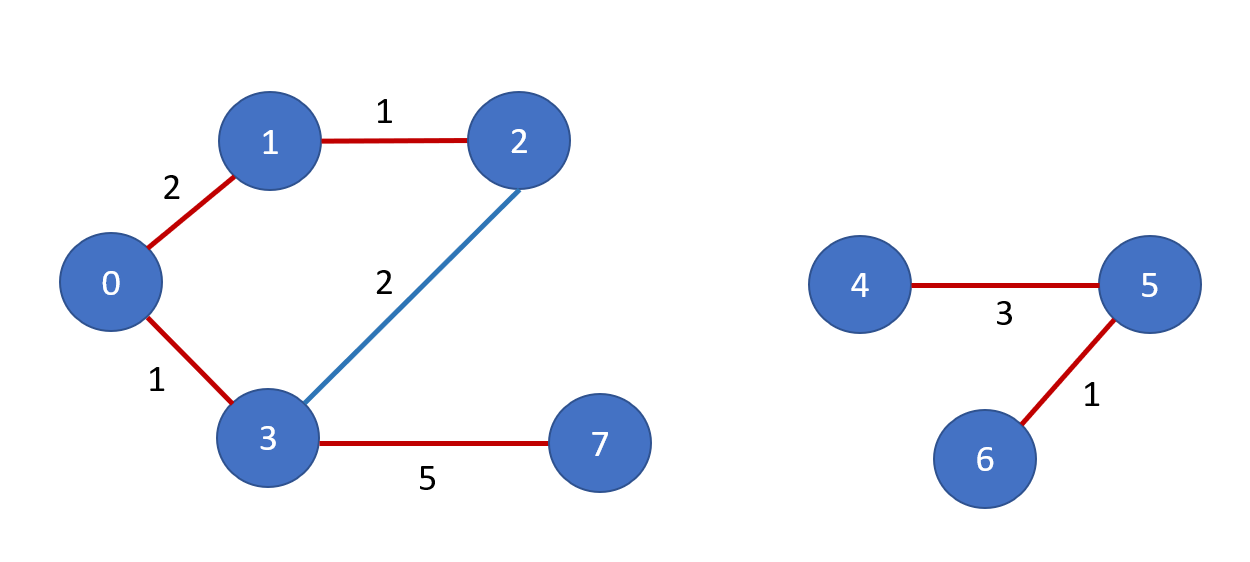

## 6. Сеть, пропускная способность, поток, разрезы. Связь максимального потока в сети и минимального разреза

**Задача.**   
Есть дом, вода из которого стекает в реку по водопроводу. Водопровод — это набор однонаправленных труб, концы которых соединены с домом, рекой или одним из $n$ соединительных узлов. Также для каждой трубы известна ее прочность — сколько воды она может выдержать. Необходимо найти максимальный объем воды, который может вытекать из дома в единицу времени.

Поставим задачу более формально. Есть граф в котором выделены две вершины, соответствующие дому $s$ и реке $t$, а остальные вершины соответствуют узлам. Ребра этого графа соответствуют трубам водопровода, и у каждого ребра есть пропускная способность — максимальное количество воды, которое может по нему течь. Обозначим за $c(v,u)$ пропускную способность ребра из $v$ в $u$, а $f(v,u)$ — количество воды, текущее по нему.

Заметим некоторые свойства воды, текущей в водопроводе. Например, для любой вершины, которая соответствует узлу, объем втекающей в неё воды равен объему вытекающей из неё воды:
$∑_u f(u,v)= ∑_u f(v,u)$
Это значит, что вода не может появится из ниоткуда и исчезнуть в никуда.

Также удобно считать, что у любого ребра есть ровно одно обратное, и $f(v,u)=−f(u,v)$, то есть если по ребру из $v$ в
$u$ перетекает $x$ потока, то по ребру из $u$ в $v$ перетекает
$−x$ потока.

Теперь замечание о втекающем и вытекающем объеме звучит так, что для любой вершины $v$, кроме истока $s$ и стока $t$: $∑_u f(v,u)=0$

Наша задача тогда — это найти такую функцию $f$, максимизирующую
$∑f(s,u)=∑f(u,t)$, удовлетворяющую предыдущим равенствам, и при этом не превышающая ни одну пропускную способность: $f(v,u)≤c(v,u)$


Если кратко, то о свойствах можно сказать следующее:

1) Сеть (flow network) — это ориентированный граф:
$G=(V,E)$
с дополнительными условиями:
* есть исток $s$ (source)
* есть сток $t$ (sink)
* каждому ребру $(u,v)$ сопоставлена пропускная способность $c(u,v)≥0$

2) Пропускная способность
* Пропускная способность (capacity) — максимальный поток, который можно пропустить по ребру.
$c(u,v)$

3) Поток
* Поток — это функция: $f(u,v)$ которая удовлетворяет трём условиям:

1. Ограничение пропускной способности
$0≤f(u,v)≤c(u,v)$
2. Антисимметрия
$f(u,v)=−f(v,u)$
3. Сохранение потока

Для любой вершины, кроме $s$ и $t$:
$∑f(вход)=∑f(выход)$

👉 сколько вошло — столько и вышло

4) Величина потока
$∣f∣=∑f(s,v)$ #сумма по v (сколько вышло из источника)

5) Разрез (cut)  
Разрез — это разбиение вершин:
$V=S∪T$, где: $s∈S$, $t∈T$




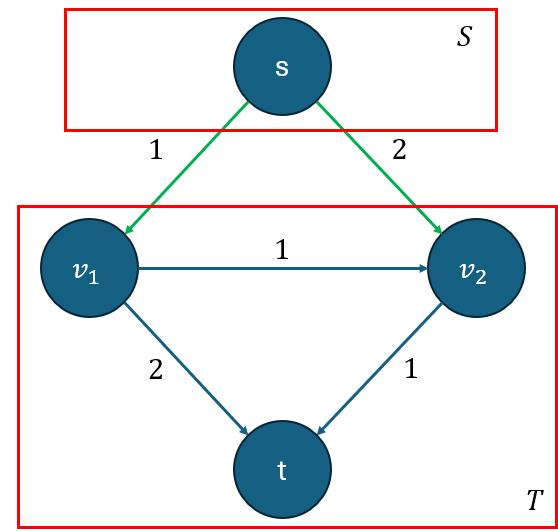

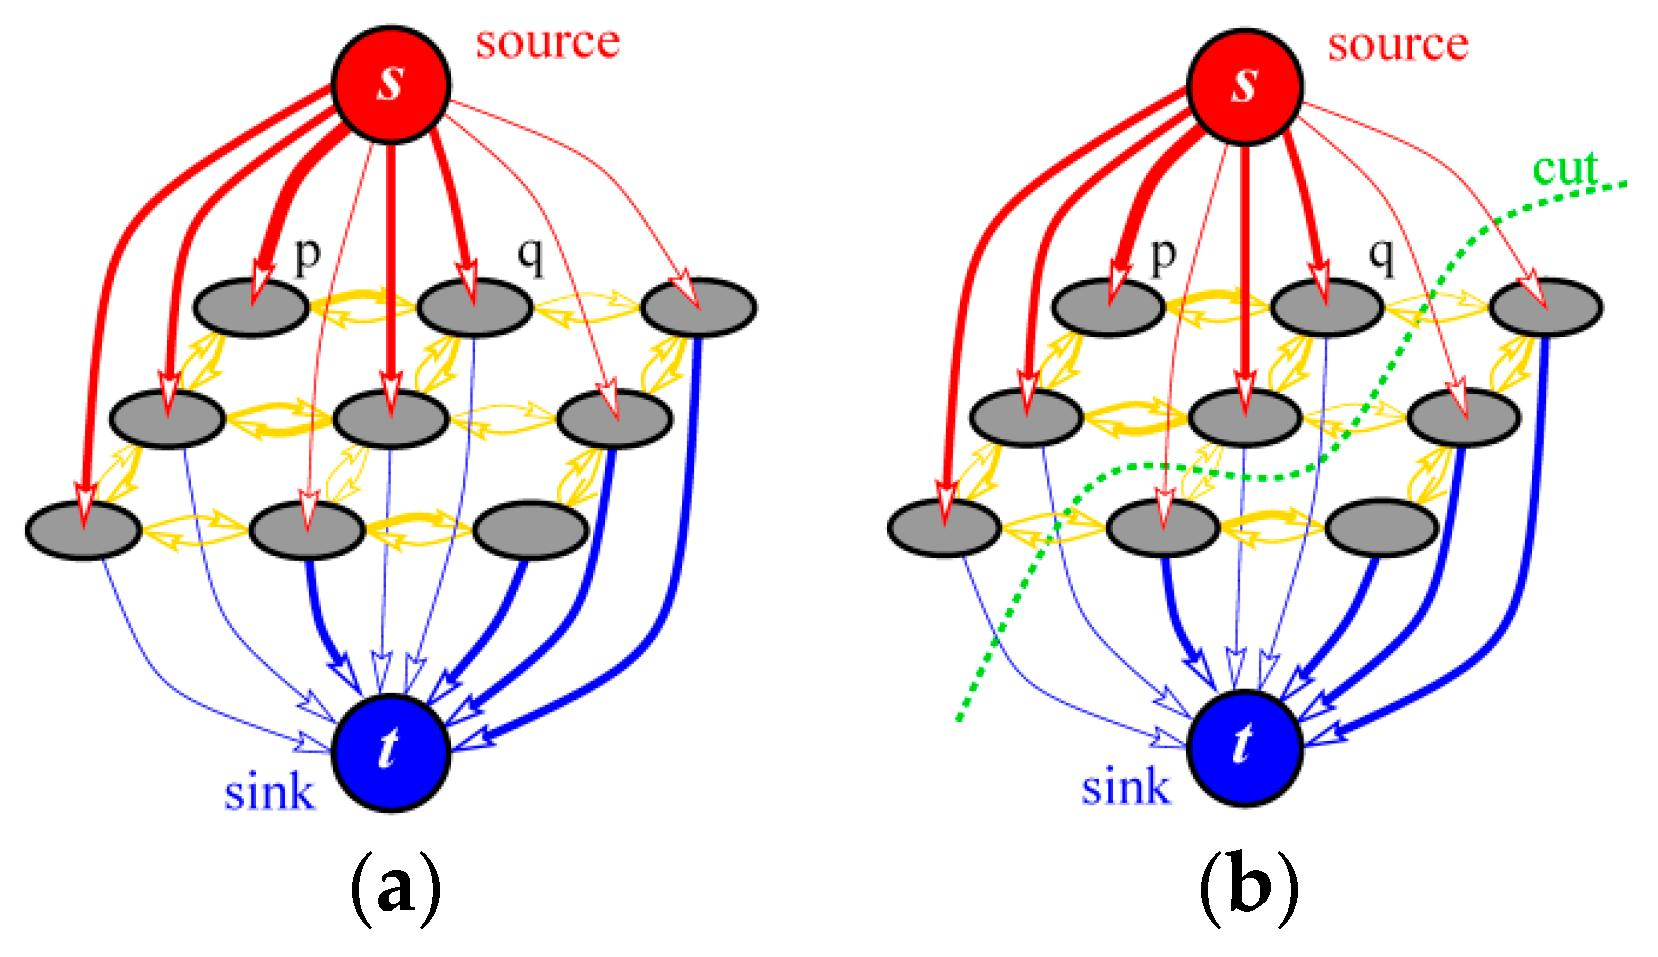

6) Пропускная способность разреза
$c(S,T)= /u∈S,v∈T/ = ∑c(u,v)$ сумма всех рёбер, идущих из S в T

7) Связь: поток и разрез  
**Теорема** (Max-Flow Min-Cut):  
Максимальный поток из s в t равен минимальному разрезу: $maxf=min(c(S,T))$

👉 Поток ограничен “узкими местами” сети:
можно качать сколько угодно, но “бутылочное горлышко” (разрез) ограничивает поток


## 7. Префикс-функция, эффективный алгоритм подсчета префикс-функции. Алгоритм КМП.

**Определение**. Префикс-функцией от строки $s$ называется массив $p$, где $p_i$ равно длине самого большого префикса строки
$s_0s_1s_2…s_i$, который также является и суффиксом $i$-того префикса (не считая весь $i$-й префикс).

Например, самый большой префикс, который равен суффиксу для строки «aataataa» — это «aataa»; префикс-функция для этой строки равна [0, 1, 0, 1, 2, 3, 4, 5].

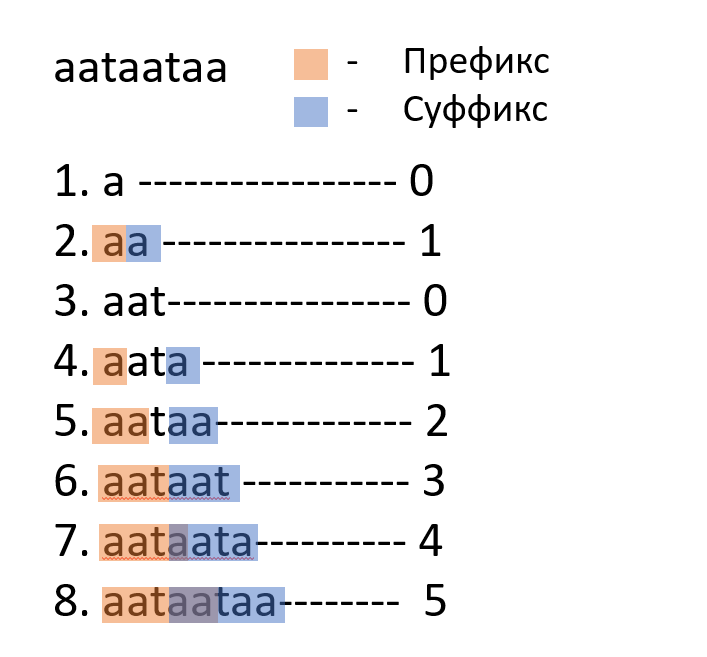

### Алгоритм Кнута-Морриса-Пратта (KMP)

KMP был разработан Дональдом Кнутом, Воаном Праттом и Джеймсом Моррисом в 1977 году. Он широко используется в поисковых системах, компиляторах и текстовых редакторах.

**Наивный подход и то, как KMP его преодолевает**  
В наивном алгоритме сопоставления строк мы выравниваем шаблон в каждой точке текста и сравниваем символы по одному. Если возникает несоответствие, мы смещаем шаблон на одну позицию и начинаем заново. Это может привести к многократной проверке одних и тех же символов, особенно в случаях с повторяющимися символами. Например, поиск «aaaab» в «aaaaaaaab» приводит к множеству ненужных сравнений, что приводит к временной сложности $O(n × m)$.

Алгоритм KMP избегает этой неэффективности, предварительно обрабатывая паттерн (шаблон) с помощью вспомогательного массива, называемого **LPS (Longest Prefix Suffix)**. Этот массив хранит длину самого длинного правильного префикса, который также является суффиксом для каждого префикса шаблона. Когда возникает несоответствие, KMP использует эту информацию, чтобы разумно изменить паттерн, пропуская позиции, которые гарантированно не совпадут — вместо того чтобы начинать заново. Это гарантирует, что каждый символ в тексте сравнивается не более одного раза, снижая временную сложность до $O(n + m)$.

**Правильный префикс**: Правильный префикс строки — это префикс, который не равен самой строке.
Например, собственные префиксы «abcd» — это: «a», «ab» и «abc».

**Массив LPS (Самый длинный префиксный суффикс)**  
Массив LPS хранит для каждой позиции в шаблоне длину самого длинного собственного префикса, который также является суффиксом подстроки, заканчивающейся на этой позиции.
Он помогает алгоритму KMP определить, насколько сильно сместить паттерн при возникновении несоответствия, не перепроверяя совпадающие символы.

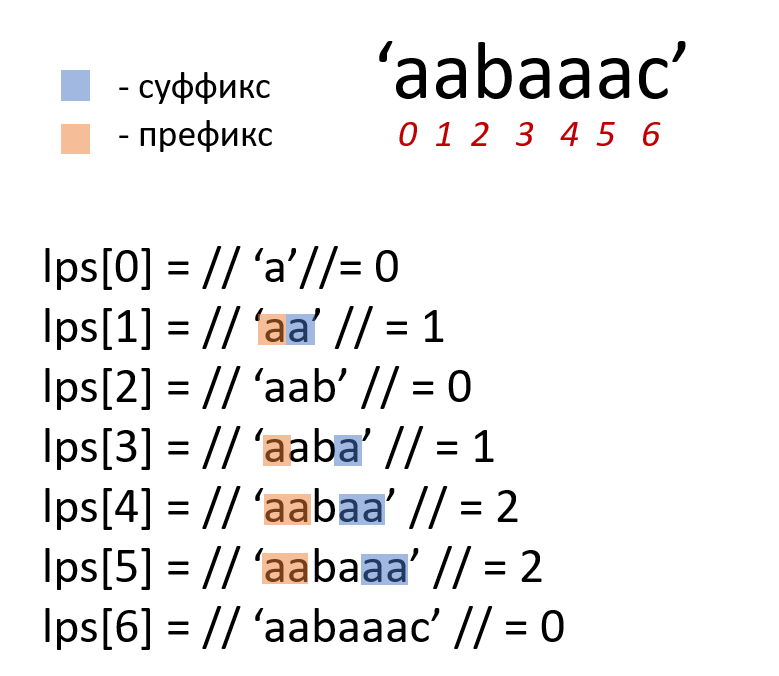

### Пример построения массива LPS

https://www.geeksforgeeks.org/dsa/kmp-algorithm-for-pattern-searching/?ysclid=mn7k6ag371870200810

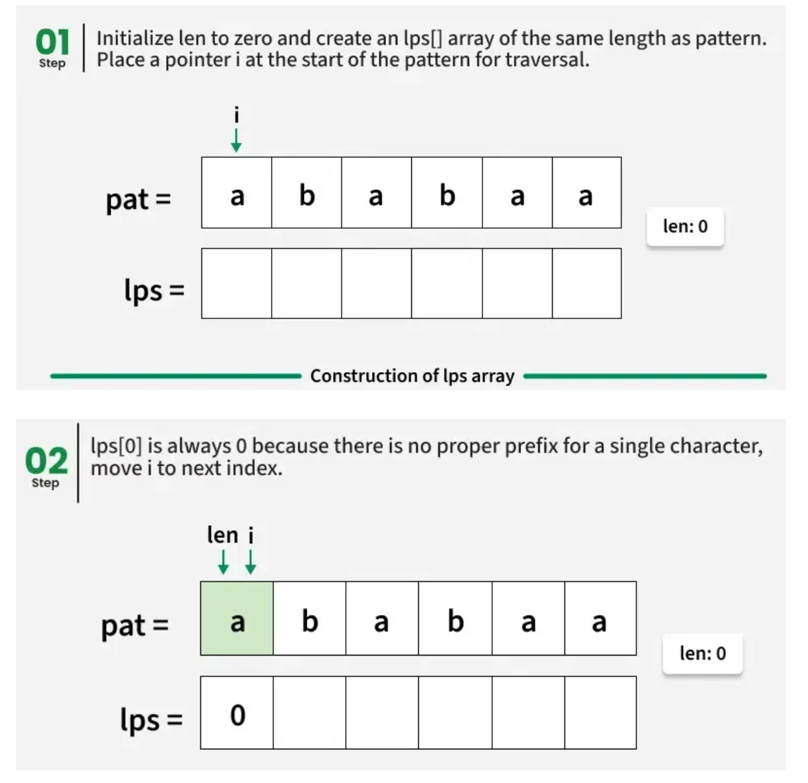

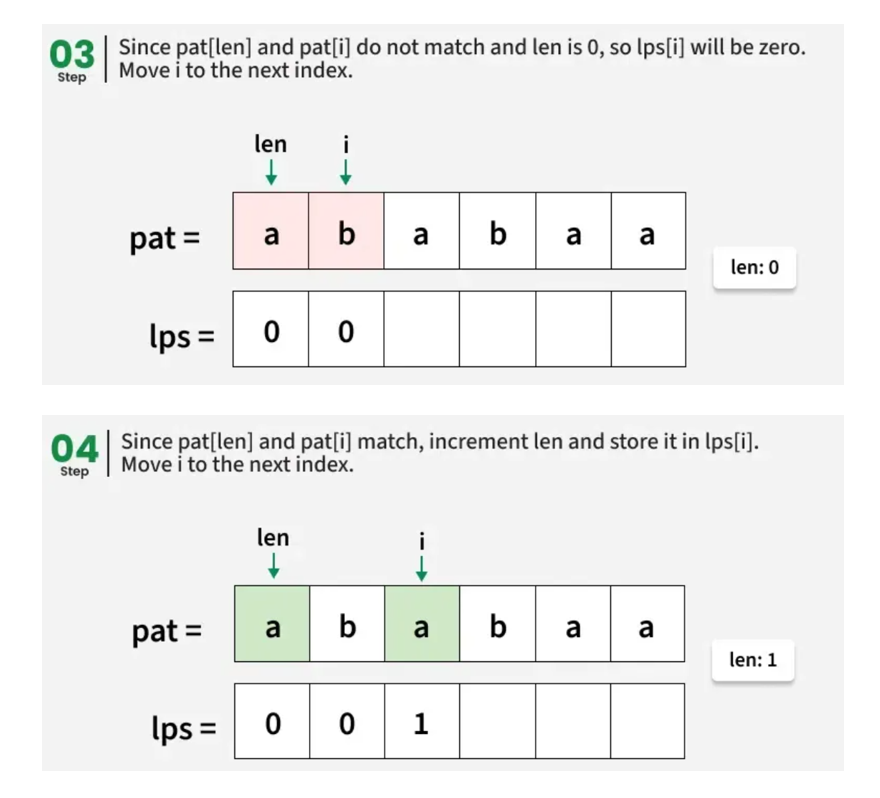

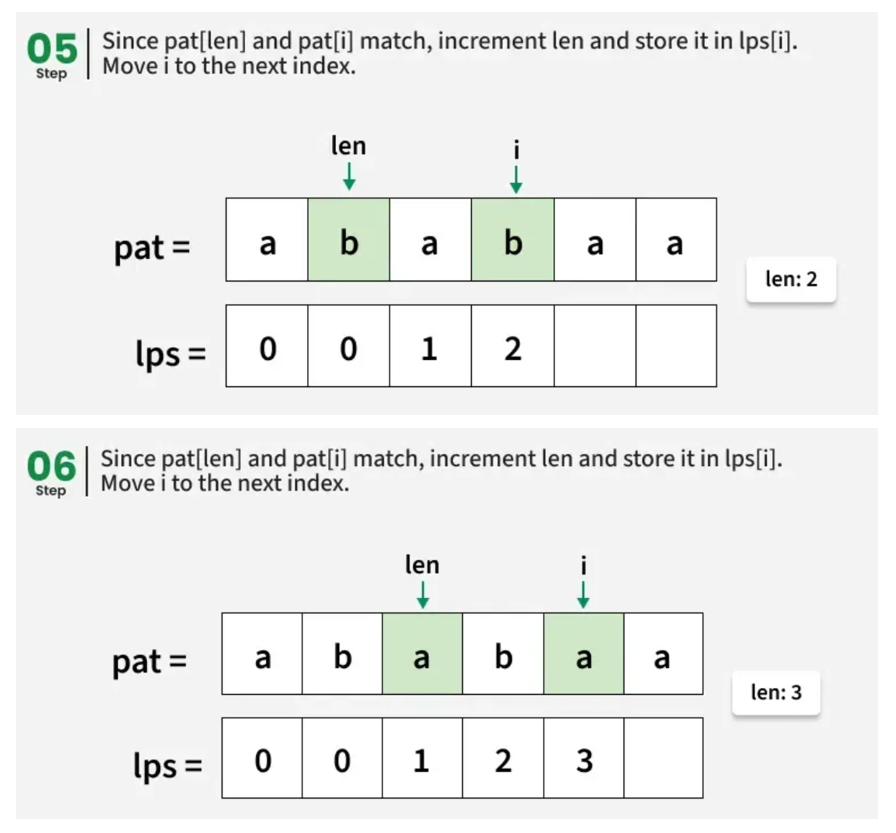

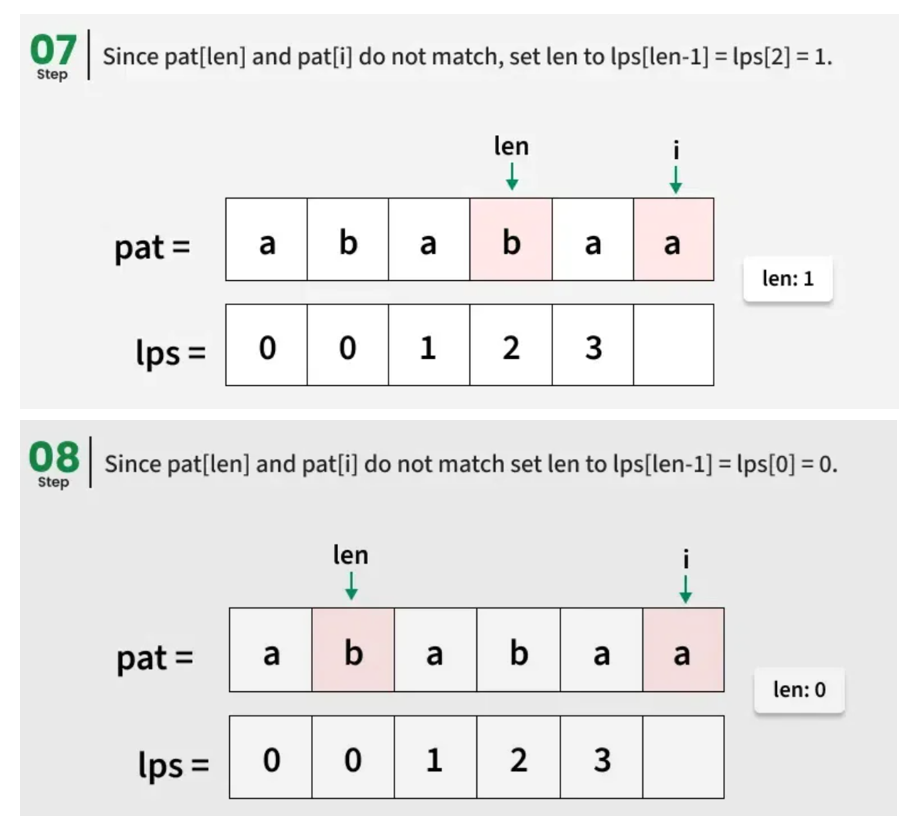

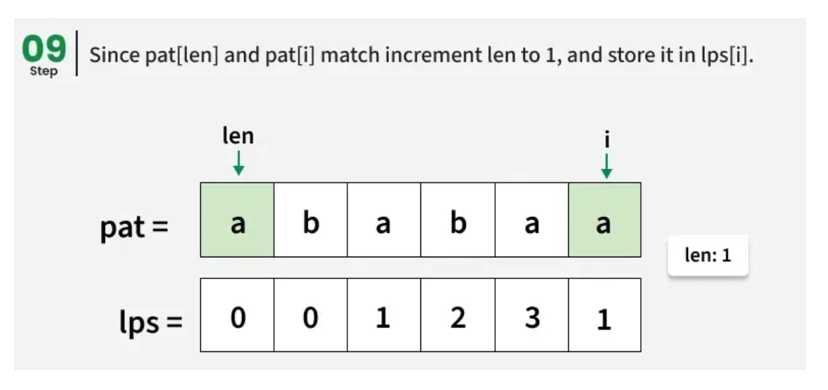

In [ ]:
def computeLPSArray(pattern):
    n = len(pattern)
    lps = [0] * n

    # length of the previous longest prefix suffix
    len1 = 0
    i = 1

    while i < n:
        if pattern[i] == pattern[len1]:
            len1 += 1
            lps[i] = len1
            i += 1
        else:
            if len1 != 0:
                # fall back in the pattern
                len1 = lps[len1 - 1]
            else:
                lps[i] = 0
                i += 1

    return lps

pattern = "ababcab"
print(computeLPSArray(pattern))

[0, 0, 1, 2, 0, 1, 2]


**Временная сложность**: $O(n)$, каждый символ в шаблоне обрабатывается не более двух раз — один раз при движении вперёд (i++) и, возможно, ещё раз при отступлении с помощью шага len = lps[len - 1].

**Вспомогательное пространство**: $O(n)$, используется дополнительный массив lps[] размера, равного шаблону.

In [ ]:
def constructLps(pat, lps):

    # len stores the length of longest prefix which
    # is also a suffix for the previous index
    len_ = 0
    m = len(pat)

    # lps[0] is always 0
    lps[0] = 0

    i = 1
    while i < m:

        # If characters match, increment the size of lps
        if pat[i] == pat[len_]:
            len_ += 1
            lps[i] = len_
            i += 1

        # If there is a mismatch
        else:
            if len_ != 0:

                # Update len to the previous lps value
                # to avoid redundant comparisons
                len_ = lps[len_ - 1]
            else:

                # If no matching prefix found, set lps[i] to 0
                lps[i] = 0
                i += 1

def search(pat, txt):
    n = len(txt)
    m = len(pat)

    lps = [0] * m
    res = []

    constructLps(pat, lps)

    # Pointers i and j, for traversing
    # the text and pattern
    i = 0
    j = 0

    while i < n:

        # If characters match, move both pointers forward
        if txt[i] == pat[j]:
            i += 1
            j += 1

            # If the entire pattern is matched
            # store the start index in result
            if j == m:
                res.append(i - j)

                # Use LPS of previous index to
                # skip unnecessary comparisons
                j = lps[j - 1]

        # If there is a mismatch
        else:

            # Use lps value of previous index
            # to avoid redundant comparisons
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1
    return res

if __name__ == "__main__":
    txt = "aabaacaadaabaaba"
    pat = "aaba"

    res = search(pat, txt)
    for i in range(len(res)):
        print(res[i], end=" ")

0 9 12 

**Временная сложность**: $O(n + m)$, где $n$ — длина текста, а $m$ — длина шаблона. Это связано с тем, что создание массива LPS (Longest Prefix Suffix) занимает $O(m)$ времени, а поиск по тексту — $O(n)$ времени.  
**Вспомогательное пространство**: $O(m)$, так как нам нужно хранить массив LPS размера $m$.

## 8. Z-функция, эффективный алгоритм подсчета z-функции. Алгоритм КМП.

### Z-функция строки и её вычисление
Пусть дана строка $s$ длины $n$. Тогда $Z$-функция ("зет-функция") от этой строки — это массив длины $n$, $i$-ый элемент которого равен наибольшему числу символов, начиная с позиции $i$, совпадающих с первыми символами строки $s$.

Иными словами, $z[i]$ — это наибольший общий префикс строки $s$ и её $i$-го суффикса.

**Примечание**. В данной статье, во избежание неопределённости, мы будем считать строку 0-индексированной — т.е. первый символ строки имеет индекс 0, а последний — $n-1$.

Первый элемент $Z$-функции, $z[0]$, обычно считают неопределённым. В данной статье мы будем считать, что он равен нулю (хотя ни в алгоритме, ни в приведённой реализации это ничего не меняет).

В данной статье приводится алгоритм вычисления $Z$-функции за время $O(n)$, а также различные применения этого алгоритма.

Приведём для примера подсчитанную Z-функцию для нескольких строк:
```
'aaaaa':
 z[0] = 0,
 z[1] = 4,
 z[2] = 3,
 z[3] = 2,
 z[4] = 1.

'aaabaab':
 z[0] = 0,
 z[1] = 2,
 z[2] = 1,
 z[3] = 0,
 z[4] = 2,
 z[5] = 1,
 z[6] = 0.

'abacaba':
 z[0] = 0,
 z[1] = 0,
 z[2] = 1,
 z[3] = 0,
 z[4] = 3,
 z[5] = 0,
 z[6] = 1.
```

### Эффективный алгоритм вычисления Z-функции
Чтобы получить эффективный алгоритм, будем вычислять значения $z[i]$ по очереди — от $i=1$ до $n-1$, и при этом постараемся при вычислении очередного значения $z[i]$ максимально использовать уже вычисленные значения.

Назовём для краткости подстроку, совпадающую с префиксом строки s, отрезком совпадения. Например, значение искомой $Z$-функции $z[i]$ — это длиннейший отрезок совпадения, начинающийся в позиции $i$ (и заканчиваться он будет в позиции $i + z[i] - 1$).

Для этого будем поддерживать координаты $[l;r]$ самого правого отрезка совпадения, т.е. из всех обнаруженных отрезков будем хранить тот, который оканчивается правее всего. В некотором смысле, индекс $r$ — это такая граница, до которой наша строка уже была просканирована алгоритмом, а всё остальное — пока ещё не известно.

Тогда если текущий индекс, для которого мы хотим посчитать очередное значение $Z$-функции, — это $i$, мы имеем один из двух вариантов:

1) $i > r$ — т.е. текущая позиция лежит за пределами того, что мы уже успели обработать.  
Тогда будем искать $z[i]$ тривиальным алгоритмом, т.е. просто пробуя значения $z[i]=0$, $z[i]=1$, и т.д. Заметим, что в итоге, если $z[i]$ окажется $>0$, то мы будем обязаны обновить координаты самого правого отрезка $[l;r]$ — т.к. $i + z[i] - 1$ гарантированно окажется больше $r$.

2) $i \le r$ — т.е. текущая позиция лежит внутри отрезка совпадения $[l;r]$.  
Тогда мы можем использовать уже подсчитанные предыдущие значения $Z$-функции, чтобы проинициализировать значение $z[i]$ не нулём, а каким-то возможно бОльшим числом.

Для этого заметим, что подстроки $s[l \ldots r]$ и $s[0 \ldots r-l]$ совпадают. Это означает, что в качестве начального приближения для $z[i]$ можно взять соответствующее ему значение из отрезка $s[0 \ldots r-l]$, а именно, значение $z[i-l]$.

Однако значение $z[i-l]$ могло оказаться слишком большим: таким, что при применении его к позиции $i$ оно "вылезет" за пределы границы $r$. Этого допустить нельзя, т.к. про символы правее $r$ мы ничего не знаем, и они могут отличаться от требуемых.

Приведём пример такой ситуации, на примере строки 'aaaabaa':

Когда мы дойдём до последней позиции ($i=6$), текущим самым правым отрезком будет $[5;6]$. Позиции 6 с учётом этого отрезка будет соответствовать позиция $6-5=1$, ответ в которой равен $z[1] = 3$. Очевидно, что таким значением инициализировать $z[6]$ нельзя, оно совершенно некорректно. Максимум, каким значением мы могли проинициализировать — это 1, поскольку это наибольшее значение, которое не вылазит за пределы отрезка $[l;r]$.

Таким образом, в качестве начального приближения для $z[i]$ безопасно брать только такое выражение:

 $z_0[i] = \min (r-i+1, z[i-l])$.

Проинициализировав $z[i]$ таким значением $z_0[i]$, мы снова дальше действуем тривиальным алгоритмом — потому что после границы $r$, вообще говоря, могло обнаружиться продолжение отрезка совпадение, предугадать которое одними лишь предыдущими значениями $Z$-функции мы не могли.

Таким образом, весь алгоритм представляет из себя два случая, которые фактически различаются только начальным значением $z[i]$: в первом случае оно полагается равным нулю, а во втором — определяется по предыдущим значениям по указанной формуле. После этого обе ветки алгоритма сводятся к выполнению тривиального алгоритма, стартующего сразу с указанного начального значения.

Алгоритм получился весьма простым. Несмотря на то, что при каждом $i$ в нём так или иначе выполняется тривиальный алгоритм — мы достигли существенного прогресса, получив алгоритм, работающий за линейное время. Почему это так, рассмотрим ниже, после того, как приведём реализацию алгоритма.



In [ ]:
def z_function(s):
    n = len(s)
    z = [0] * n
    l = r = 0

    for i in range(1, n):
        if i <= r:
            z[i] = min(r - i + 1, z[i - l])

        while i + z[i] < n and s[z[i]] == s[i + z[i]]:
            z[i] += 1

        if i + z[i] - 1 > r:
            l, r = i, i + z[i] - 1

    return z

In [ ]:
s = 'aaaabaa'
z = z_function(s)
print(z)

[0, 3, 2, 1, 0, 2, 1]


Всё решение оформлено в виде функции, которая по строке возвращает массив длины $n$ — вычисленную $Z$-функцию.

Массив $z[]$ изначально заполняется нулями. Текущий самый правый отрезок совпадения полагается равным $[0;0]$, т.е. заведомо маленький отрезок, в который не попадёт ни одно $i$.

Внутри цикла по $i = 1 \ldots n-1$ мы сначала по описанному выше алгоритму определяем начальное значение $z[i]$ — оно либо останется нулём, либо вычислится на основе приведённой формулы.

После этого выполняется тривиальный алгоритм, который пытается увеличить значение $z[i]$ настолько, насколько это возможно.

В конце выполняется обновление текущего самого правого отрезка совпадения $[l;r]$, если, конечно, это обновление требуется — т.е. если $i+z[i]-1 > r$.

### Асимптотика алгоритма
Докажем, что приведённый выше алгоритм работает за линейное относительно длины строки время, т.е. за $O(n)$.

Доказательство очень простое.

Нас интересует вложенный цикл $\rm while$ — т.к. всё остальное — лишь константные операции, выполняемые $O(n)$ раз.

Покажем, что каждая итерация этого цикла $\rm while$ приведёт к увеличению правой границы r на единицу.

Для этого рассмотрим обе ветки алгоритма:

1) $i > r$:  
В этом случае либо цикл $\rm while$ не сделает ни одной итерации (если $s[0] \ne s[i]$), либо же сделает несколько итераций, продвигаясь каждый раз на один символ вправо, начиная с позиции $i$, а после этого — правая граница $r$ обязательно обновится.

Поскольку $i > r$, то мы получаем, что действительно каждая итерация этого цикла увеличивает новое значение $r$ на единицу.

2) $i \le r$:  
В этом случае мы по приведённой формуле инициализируем значение z[i] некоторым числом z_0. Сравним это начальное значение z_0 с величиной r-i+1, получаем три варианта:

* $z_0 < r-i+1$  
Докажем, что в этом случае ни одной итерации цикл while не сделает.

Это легко доказать, например, от противного: если бы цикл $while$ сделал хотя бы одну итерацию, это бы означало, что определённое нами значение $z_0$ было неточным, меньше настоящей длины совпадения. Но т.к. строки $s[l \ldots r]$ и $s[0 \ldots r-l]$ совпадают, то это означает, что в позиции $z[i-l]$ стоит неправильное значение: меньше, чем должно быть.

Таким образом, в этом варианте из корректности значения $z[i-l]$ и из того, что оно меньше $r-i+1$, следует, что это значение совпадает с искомым значением $z[i]$.

* $z_0 = r-i+1$
В этом случае цикл $while$ может совершить несколько итераций, однако каждая из них будет приводить к увеличению нового значения r на единицу: потому что первым же сравниваемым символом будет $s[r+1]$, который вылазит за пределы отрезка $[l;r]$.

* $z_0 > r-i+1$
Этот вариант принципиально невозможен, в силу определения $z_0$.

Таким образом, мы доказали, что каждая итерация вложенного цикла приводит к продвижению указателя r вправо. Т.к. $r$ не могло оказаться больше $n-1$, это означает, что всего этот цикл сделает не более $n-1$ итерации.

Поскольку вся остальная часть алгоритма, очевидно, работает за $O(n)$, то мы доказали, что и весь алгоритм вычисления Z-функции выполняется за линейное время.


## 9. Полиномиальный хеш, его свойства, алгоритм Рабина-Карпа

### Полиномиальный хеш
Строка рассматривается как число, записанное по основанию b.
Каждый символ переводится в число (например, a → 1, b → 2, …).

Пример для строки s = "abc":

```python
h = s[0] * p^0 +
    s[1] * p^1 +
    s[2] * p^2
```


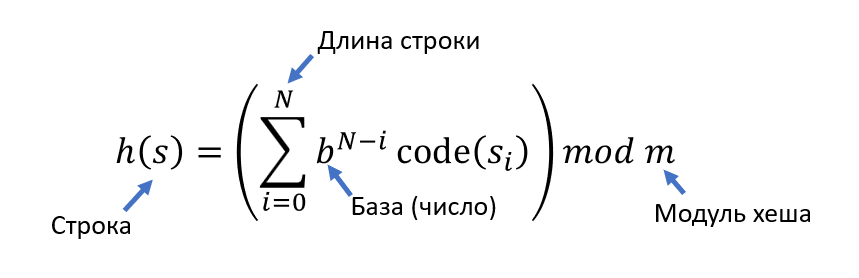

$s = s_0 s_1 s_2 s_3 s_4$  

$h(s) = s_0 b^4 + s_1 b^3 + s_2 b^2 + s_3 b^1 + s_4 b^0 $

Можно записать в виде рекурретного соотношения:

$h(prev_i) = b*h(pref_{i-1}) + code(s_{i-1})$, где $pref_{i}$ - префикс  длины $i$

$h(s_0 s_1 s_2) = h(s_0 s_1) * b + s_2$
$h(s_0 s_1) = h(s_0) * b + s_1$  
$h(s_0) = s_0$   


Как выбрать code?
- ASCII таблица
- алфавитные номера (номер символа в алфавите)
- своя код-функция

!!! Никогда не использовать 0 как код какого-либо символа !!!  
$h('a') = h('aa') =  h('aaa') = 0$


Свойства полиномиального хеша:
1. Вычисляется за $O(N)$
2. Является инъекцией, если правильно подобрать базу

Рекомендации к $b$ и $m$ для уменьшения коллизий:
1. p > max code
2. m > p
3. $m != 2^k$
4. m - простое число (желательно)


In [ ]:
def code(c):
  return ord(c) - ord('a') + 1

def poly_hash(s):
  b = 37
  h = 0
  m = 10**9 + 7
  for c in s:
    h = (h*b + code(c)) % m
  return h

print(poly_hash('abc'))
print(poly_hash('acb'))

1446
1482


### Алгоритм Рабина-Карпа  
Есть строка $S$ и шаблон $T$. Задача поиска подстроки в строке.
1. Вычисляем хеш для всего шаблона T $(O(T))$ и для всех префиксов S $(O(S))$ -> $O(n) + O(m)$
2. Возьмем подстроку длины T из S и посчитаем хеш
3. Сравним hash(T) c хешем подстроки -> $O(1)$
4. Повторим для всех подстрок

In [ ]:
def rabin_karp(text, pattern):
    n, m = len(text), len(pattern)
    if m > n:
        return []

    # параметры хеша
    p = 31              # основание полинома
    mod = 10**9 + 7     # большой модуль для уменьшения коллизий

    # ------------------------------------------
    # 1. Предвычисляем степени p:
    # ------------------------------------------
    p_pow = [1] * (n + 1)
    for i in range(1, n):
        p_pow[i] = (p_pow[i-1] * p) % mod

    # ------------------------------------------
    # 2. Префиксные хеши строки text
    #    h[i] = hash(text[0..i-1])
    # ------------------------------------------
    h = [0] * (n + 1)
    for i in range(n):
        h[i+1] = (h[i] + (ord(text[i]) - ord('a') + 1) * p_pow[i]) % mod

    # ------------------------------------------
    # 3. Хеш шаблона pattern
    # ------------------------------------------
    pattern_hash = 0
    for i in range(m):
        pattern_hash = (pattern_hash + (ord(pattern[i]) - ord('a') + 1) * p_pow[i]) % mod

    # ------------------------------------------
    # 4. Перебираем все позиции text, сравниваем хеши
    # ------------------------------------------
    result = []
    for i in range(n - m + 1):
        # Хеш подстроки text[i : i+m]
        # Используем формулу префиксных хешей:
        #   h_sub = h[i+m] - h[i]
        cur_hash = (h[i + m] - h[i] + mod) % mod

        # Чтобы хеши были в одной "степени":
        #   pattern_hash * p^i
        if cur_hash == (pattern_hash * p_pow[i] % mod):
            # Хеши совпали → возможное совпадение
            # Проверяем напрямую, чтобы исключить редкие коллизии
            if text[i:i+m] == pattern:
                result.append(i)

    return result

print(rabin_karp("abracadabra", "abra"))


[0, 7]


Фанфакт из вики, если Вы дочитали до этого момента :) :  
Одно из простейших практических применений алгоритма Рабина — Карпа состоит в определении плагиата. Скажем, например, что студент пишет работу по Моби Дику. Коварный профессор находит различные исходные материалы по Моби Дику и автоматически извлекает список предложений в этих материалах. Затем алгоритм Рабина — Карпа может быстро найти в проверяемой статье примеры вхождения некоторых предложений из исходных материалов. Для устранения чувствительности алгоритма к небольшим различиям можно игнорировать детали, такие как регистр или пунктуация, при помощи их удаления. Поскольку количество строк, которые мы ищем, k, очень большое, обычные алгоритмы поиска одиночных строк становятся неэффективными.

## 10. Выпуклая оболочка, алгоритм построения.

**Выпуклое множество** — такое множество точек, что, для любых двух точек множества, все точки на отрезке между ними тоже принадлежат этому множеству.

* Выпуклая оболочка множества точек — такое выпуклое множество точек, что все точки фигуры также лежат в нем.

* Минимальная выпуклая оболочка множества точек — это минимальная по площади выпуклая оболочка.

Для экономии времени дальше минимальные выпуклые оболочки мы будем называть просто выпуклыми оболочками.


Для практических целей выпуклые оболочки полезны тем, что они компактно хранят всю необходимую информацию о множестве точек, что позволяет быстро отвечать на разнообразные запросы на этом множестве.


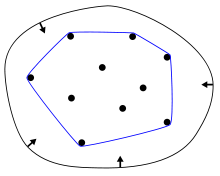

### Алгоритм Джарвиса
Одним из самых простых алгоритмов построения выпуклой оболочки является алгоритм Джарвиса.

Выберем какую-нибудь точку $p_0$, которая гарантированно попадёт в выпуклую оболочку. Например, нижнюю, а если таких несколько, то самую левую из них.

Дальше будем действовать так: найдём самую «правую» точку от последней добавленной (то есть точку с минимальным полярным углом относительно неё) и добавим её в оболочку. Будем так итеративно добавлять точки, пока не «замкнёмся», то есть пока самой правой точкой не станет $p_0$.

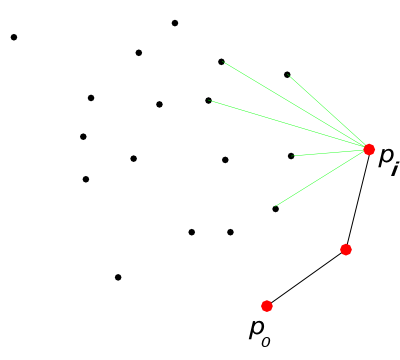

In [ ]:
class Point:
    """Точка на плоскости с целыми координатами."""
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __sub__(self, other):
        return Point(self.x - other.x, self.y - other.y)

    def cross(self, other):
        """Векторное произведение (псевдоскаляр)."""
        return self.x * other.y - self.y * other.x

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __str__(self):
        return f"({self.x}, {self.y})"


def jarvis(points):
    """
    Алгоритм Джарвиса (метод заворачивания подарка).
    Возвращает список вершин выпуклой оболочки в порядке обхода против часовой стрелки.
    Предполагается:
      - все точки различны;
      - нет трёх коллинеарных точек на оболочке (для простоты);
      - координаты целые.
    """
    n = len(points)
    if n < 3:
        return points[:]  # оболочка из всех точек

    # 1. Находим самую нижнюю и левую точку (гарантированно в оболочке)
    p0 = points[0]
    for p in points:
        if p.y < p0.y or (p.y == p0.y and p.x < p0.x):
            p0 = p

    hull = []
    current = p0

    while True:
        hull.append(current)
        # Ищем следующую точку: она должна иметь максимальный полярный угол
        # относительно текущей (т.е. все остальные точки лежат "левее" от вектора current->next).
        next_point = points[0]  # временный кандидат
        for p in points:
            if p == current:
                continue
            # Если next_point ещё не задан, берём первый попавшийся
            if next_point == current:
                next_point = p
                continue
            # Векторное произведение (current->p) x (current->next_point)
            # Если оно > 0, значит p левее текущего кандидата -> выбираем p
            if (p - current).cross(next_point - current) > 0:
                next_point = p
        # Проверяем, замкнули ли оболочку
        if next_point == p0:
            break
        current = next_point

    return hull


# ========== Пример использования ==========
if __name__ == "__main__":
    pts = [Point(0, 3), Point(1, 2), Point(2, 1), Point(3, 0),
           Point(2, -1), Point(1, -2), Point(0, -3),
           Point(-1, -2), Point(-2, -1), Point(-3, 0),
           Point(-2, 1), Point(-1, 2)]

    hull = jarvis(pts)
    print("Выпуклая оболочка:")
    for p in hull:
        print(p)

Выпуклая оболочка:
(0, -3)
(3, 0)
(0, 3)
(-3, 0)


Для каждой точки выпуклой оболочки (обозначим их количество за
$h$) мы из всех оставшихся $O(n)$ точек будем искать оптимальную, что суммарно будет работать за $O(nh)$.

Важно помнить, что асимптотика именно $O(nh)$, а не $O(n^2)$: существуют задачи, где оболочка маленькая, и это существенно.

## Алгоритм Грэхэма

Алгоритм Грэхэма — это оптимизация алгоритма Джарвиса, основанная на следующем наблюдении: если отсортировать все точки по полярному углу относительно точки $p_0$, то выпуклая оболочка будет какой-то подпоследовательностью такого отсортированного массива точек.

Алгоритм последовательно строит выпуклые оболочки для каждого префикса этого отсортированного массива. Можно заметить, что при добавлении $i$-й точки в оболочку нужно лишь удалить сколько-то последних добавленных точек, которые не будут входить в новую оболочку, а именно тех, которые «покрываются» новой точкой и своей предыдущей.

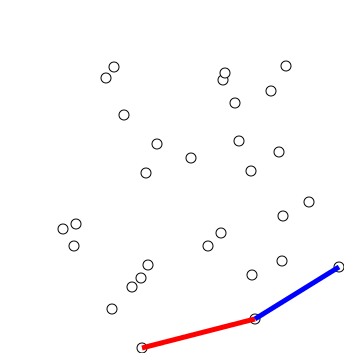

https://ru.algorithmica.org/cs/convex-hulls/graham/

Чтобы проводить это удаление эффективно, мы можем хранить выпуклую оболочку в стеке и в цикле while смотреть на три последние точки и проверять, образуют ли они правый поворот. Если это так, то среднюю следует удалить — мы нашли треугольник ($p_0,p_i,p_{i−2}$), который содержит $p_{i−1}$, а значит её можно удалить.

Каждая точка будет добавлена один раз удалена не более одного раза, что занимает константное количество операций. Соответственно, время работы будет упираться во время работы сортировки, то есть $O(nlogn)$.

In [ ]:
import math
from functools import cmp_to_key

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __sub__(self, other):
        return Point(self.x - other.x, self.y - other.y)

    def cross(self, other):
        """Векторное произведение (псевдоскаляр)."""
        return self.x * other.y - self.y * other.x

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __str__(self):
        return f"({self.x}, {self.y})"


def graham(points):
    """
    Алгоритм Грэхема построения выпуклой оболочки.
    Возвращает список вершин в порядке обхода против часовой стрелки.
    """
    n = len(points)
    if n < 3:
        return points[:]

    # 1. Находим p0: самую нижнюю, при равенстве – самую левую
    p0 = points[0]
    for p in points[1:]:
        if p.y < p0.y or (p.y == p0.y and p.x < p0.x):
            p0 = p

    # 2. Сортируем точки по полярному углу относительно p0
    def polar_cmp(a, b):
        # Векторное произведение (a-p0) x (b-p0) > 0 => a левее b
        cross = (a - p0).cross(b - p0)
        if cross != 0:
            return -1 if cross > 0 else 1   # убывание: больший угол идёт раньше
        # Если коллинеарны – ближе к p0 идёт первой
        da = (a.x - p0.x)**2 + (a.y - p0.y)**2
        db = (b.x - p0.x)**2 + (b.y - p0.y)**2
        return -1 if da < db else 1

    sorted_points = sorted(points, key=cmp_to_key(polar_cmp))

    # 3. Строим оболочку в стеке
    hull = []
    for p in sorted_points:
        # Пока в стеке >=2 точек и новый вектор образует правый поворот (cross <= 0) – удаляем последнюю
        while len(hull) >= 2:
            a = hull[-2]
            b = hull[-1]
            # Векторы: b->p и a->b
            if (b - a).cross(p - b) <= 0:
                hull.pop()
            else:
                break
        hull.append(p)

    return hull


# ========== Пример использования ==========
if __name__ == "__main__":
    pts = [Point(0, 3), Point(1, 2), Point(2, 1), Point(3, 0),
           Point(2, -1), Point(1, -2), Point(0, -3),
           Point(-1, -2), Point(-2, -1), Point(-3, 0),
           Point(-2, 1), Point(-1, 2)]

    hull = graham(pts)
    print("Выпуклая оболочка (Грэхем):")
    for p in hull:
        print(p)

Выпуклая оболочка (Грэхем):
(0, -3)
(3, 0)
(0, 3)
(-3, 0)


Сортировка – $O(n log n)$, построение оболочки – $O(n)$.

Итоговая сложность – $O(n log n)$, что значительно быстрее алгоритма Джарвиса ($O(nh)$) для больших $n$.

## Алгоритм Чана
Как уже упоминалось ранее, иногда существенную роль играет то, что алгоритм Джарвиса работает за $O(nh)$, а не $O(n^2)$: когда известно, что оболочка небольшая, он лучше алгоритма Грэхэма за
$O(nlogn)$.

Алгоритм Чана пытается получить лучшее из двух и объединить алгоритмы Джарвиса и Грэхэма, чтобы получить асимптотику $O(nlogh)$.

**Алгоритм**. Разделим все точки на группы по $m$ точек. В каждой группе построим выпуклую оболочку за $O(mlogm)$ алгоритмом Грэхэма. Точки никак не упорядочены, и эти оболочки могут пересекаться — это нормально. Суммарно для всех групп понадобится
$O(nlogm)$ операций.

Затем, начиная с самой левой нижней точки, мы будем строить общую выпуклую оболочку аналогично алгоритму Джарвиса, но теперь «самую правую точку» можно находить каждый раз не за $O(n)$, а за
$O(\frac{n}{m}logm)$, если делать бинарный поиск в каждой из
$\frac{n}{m}$ оболочек.

Получается, что такое решение будет работать за $O(h
\frac{n}{m}logm+nlogm)$. Если заранее приблизительно знать $h$, то можно положить $m=h$, и тогда асимптотика составит $O(nlogh)$.

Понятно, что ни при каких применимых на практике ограничениях, даже если оболочка состоит из трёх точек, этот алгоритм не будет быстрее обычного алгоритма Грэхэма, так что автор не будет приводить его реализацию. Этот способ просто интересен с теоретической точки зрения.

https://ru.algorithmica.org/cs/convex-hulls/chan/